In [1]:
import pandas as pd
import seaborn as sns
pd.options.display.precision = 2
import matplotlib.pyplot as plt
import json
import sys

In [2]:
sys.path.append('../')

In [3]:
League_path = '/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/Imaginary_Hammers/'

In [4]:
Calc_date = 'Mar21_2026'

In [5]:
my_TeamID = 240.

In [6]:
All_Teams_csv_path = League_path+'/Rosters'+f'/Kept_Players_and_Replacement_Level_{Calc_date}.csv'

In [7]:
All_Teams_df = pd.read_csv(All_Teams_csv_path)
All_Teams_df['FG ID'] = All_Teams_df['FG ID'].astype(str)
All_Teams_df['FG ID'] = All_Teams_df['FG ID'].str.replace('.0','')
All_Teams_df['Ottoneu ID'] = All_Teams_df['Ottoneu ID'].astype(str)
All_Teams_df['Ottoneu ID'] = All_Teams_df['Ottoneu ID'].str.replace('.0','')

In [8]:
Target_Stats_path = League_path+'/Target_Stats_dict.json'

In [9]:
Additional_targets = {
    'G_mySGP_Team':162.*12.,
    'G_FGAV_Team': 162.*12.,
    'IP_mySGP_Team':1500.,
    'IP_FGAV_Team':1500.,
    'TOTAL_SGP_Val_mySGP':500., #terget value for full team
    'R_SGP_Val_mySGP_Team':200., # Not exactly correct, but OK for now. See Cells 115 & 125 in Player SGP
    'HR_SGP_Val_mySGP_Team':200., # Not exactly correct, but OK for now. See Cells 115 & 125 in Player SGP
    'OBP_SGP_Val_mySGP_Team':200., # Not exactly correct, but OK for now. See Cells 115 & 125 in Player SGP
    'SLG_SGP_Val_mySGP_Team':200., # Not exactly correct, but OK for now. See Cells 115 & 125 in Player SGP
    'SO_SGP_Val_mySGP_Team':200., # Not exactly correct, but OK for now. See Cells 115 & 125 in Player SGP
    'HR9_SGP_Val_mySGP_Team':200., # Not exactly correct, but OK for now. See Cells 115 & 125 in Player SGP
    'ERA_SGP_Val_mySGP_Team':200., # Not exactly correct, but OK for now. See Cells 115 & 125 in Player SGP
    'WHIP_SGP_Val_mySGP_Team':200., # Not exactly correct, but OK for now. See Cells 115 & 125 in Player SGP
    'Salary': 380. #assume 10 for in-season pickups
}

Batting_value_columns = {
    'G':['TOTAL_SGP_Val_mySGP','G_mySGP_Team','PA_mySGP_Team','PA_FGAV_Team','Salary'],
    'R':['R_mySGP_Team','R_SGP_Val_mySGP_Team'], #'R_SGP_raw_mySGP','R_SGP_norm_mySGP','mR_FGAV'
    'HR':['HR_mySGP_Team','HR_SGP_Val_mySGP_Team'], # 'HR_SGP_raw_mySGP','HR_SGP_norm_mySGP','mHR_FGAV'
    'OBP':['OBP_Team','OBP_SGP_Val_mySGP_Team'], # 'OBP_SGP_raw_mySGP','OBP_SGP_norm_mySGP','mOBP_FGAV'
    'SLG':['SLG_Team','SLG_SGP_Val_mySGP_Team'] #'SLG_SGP_raw_mySGP','SLG_SGP_norm_mySGP',,'mSLG_FGAV'
}

Pitching_value_columns = {
    'IP':['TOTAL_SGP_Val_mySGP','IP_mySGP_Team','IP_FGAV_Team','Salary'],
    'SO':['SO_mySGP_Team','SO_SGP_Val_mySGP_Team'], # 'SO_SGP_raw_mySGP','SO_SGP_norm_mySGP',,'mSO_FGAV'
    'HR9':['HR9_Team','HR9_SGP_Val_mySGP_Team'], #'HR9_SGP_raw_mySGP','HR9_SGP_norm_mySGP', ,'mHR_FGAV'
    'ERA':['ERA_Team','ERA_SGP_Val_mySGP_Team'], # 'ERA_SGP_raw_mySGP','ERA_SGP_norm_mySGP',,'mERA_FGAV'
    'WHIP':['WHIP_Team','WHIP_SGP_Val_mySGP_Team'] # 'WHIP_SGP_raw_mySGP','WHIP_SGP_norm_mySGP',,'mWHIP_FGAV'
}

Team_Rate_Cols = [
    'HR9_Team',
    'ERA_Team',
    'WHIP_Team',
    'OBP_Team',
    'SLG_Team'
]

In [10]:
with open(Target_Stats_path, 'r') as f:
    data = json.load(f)
    data.update(Additional_targets)
Target_Stats_df = pd.json_normalize(data)

In [11]:
Target_Stats_df.columns

Index(['Target Pts', 'R', 'HR', 'OBP', 'SLG', 'K', 'HR9', 'ERA', 'WHIP',
       'G_mySGP_Team', 'G_FGAV_Team', 'IP_mySGP_Team', 'IP_FGAV_Team',
       'TOTAL_SGP_Val_mySGP', 'R_SGP_Val_mySGP_Team', 'HR_SGP_Val_mySGP_Team',
       'OBP_SGP_Val_mySGP_Team', 'SLG_SGP_Val_mySGP_Team',
       'SO_SGP_Val_mySGP_Team', 'HR9_SGP_Val_mySGP_Team',
       'ERA_SGP_Val_mySGP_Team', 'WHIP_SGP_Val_mySGP_Team', 'Salary'],
      dtype='str')

In [12]:
Target_Stats_Hitter_df = Target_Stats_df[['Target Pts','R','HR','OBP','SLG','G_mySGP_Team','G_FGAV_Team','TOTAL_SGP_Val_mySGP','R_SGP_Val_mySGP_Team', 'HR_SGP_Val_mySGP_Team', 'OBP_SGP_Val_mySGP_Team', 'SLG_SGP_Val_mySGP_Team','Salary']]
Target_Stats_Hitter_df['Hitter Pitcher'] = 'Hitter'
Target_Stats_Hitter_df.rename(columns={'R':'R_mySGP_Team','HR':'HR_mySGP_Team','OBP':'OBP_Team','SLG':'SLG_Team'},inplace=True)
Target_Stats_Pitcher_df = Target_Stats_df[['Target Pts','K','HR9','ERA','WHIP','IP_mySGP_Team','IP_FGAV_Team','TOTAL_SGP_Val_mySGP','SO_SGP_Val_mySGP_Team', 'HR9_SGP_Val_mySGP_Team', 'ERA_SGP_Val_mySGP_Team', 'WHIP_SGP_Val_mySGP_Team','Salary']]
Target_Stats_Pitcher_df['Hitter Pitcher'] = 'Pitcher'
Target_Stats_Pitcher_df.rename(columns={'K':'SO_mySGP_Team','HR9':'HR9_Team','ERA':'ERA_Team','WHIP':'WHIP_Team'},inplace=True)
#Target_Stats_Pitcher_df[] = 
Target_Stats_df = pd.concat([
    Target_Stats_Hitter_df,
    Target_Stats_Pitcher_df
])

In [13]:
Target_Stats_df.head()

,Target Pts,R_mySGP_Team,HR_mySGP_Team,OBP_Team,SLG_Team,G_mySGP_Team,G_FGAV_Team,TOTAL_SGP_Val_mySGP,R_SGP_Val_mySGP_Team,HR_SGP_Val_mySGP_Team,...,SO_mySGP_Team,HR9_Team,ERA_Team,WHIP_Team,IP_mySGP_Team,IP_FGAV_Team,SO_SGP_Val_mySGP_Team,HR9_SGP_Val_mySGP_Team,ERA_SGP_Val_mySGP_Team,WHIP_SGP_Val_mySGP_Team
0,10.44,1073.34,323.02,0.34,0.46,1944.0,1944.0,500.0,200.0,200.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,10.44,NaN,NaN,NaN,NaN,NaN,NaN,500.0,NaN,NaN,...,1634.48,0.99,3.38,1.13,1500.0,1500.0,200.0,200.0,200.0,200.0


In [14]:
Player_id_cols = [
    'FG ID','Name','Team','Ottoneu ID','Ottoneu Positions'
]

In [15]:
Fantasy_Team_ID_cols = [
    'TeamID', 'Team Name',
]

In [16]:
Games_IP_Targets = {
    'C':162,
    '1B':162,
    '2B':162,
    '3B':162,
    'SS':162,
    'MI':162, 
    'OF':810, #total
    'Util':162, 
    'IP':1500 #total
}
Start_Spots = {
    'C':1, #technically 2 but 162 G limit
    '1B':1,
    '2B':1,
    'SS':1,
    'MI':1,
    '3B':1,
    'OF':5,
    'Util':1, #starting Hitters
    'SP':5,
    'RP':5
}

Total_Roster_Spots = {
    'C':2,
    '1B':2,
    '2B':3,
    'SS':3,
    '3B':2,
    'OF':9,
    'SP':9,
    'RP':6
}

In [17]:
#Scoring Categories
Count_Scoring_Categories_Batting = [
    'R',
    'HR'
]
Rate_Scoring_Categories_Batting = [
    'OBP',
    'SLG'
]
Count_Scoring_Categories_Pitching = [
    'SO'
]
Rate_Scoring_Categories_Pitching = [
    "HR9",
    "ERA",
    "WHIP"
]
Num_teams = 12.
Team_budget = 400.
Hitter_sal_split = 0.53
League_budget = Team_budget*Num_teams
Hitter_budget = League_budget*Hitter_sal_split
Pitcher_budget = League_budget*(1.-Hitter_sal_split)
Scoring_Categories_Batting = Count_Scoring_Categories_Batting + Rate_Scoring_Categories_Batting
Scoring_Categories_Pitching = Count_Scoring_Categories_Pitching + Rate_Scoring_Categories_Pitching
Scoring_Categories = Scoring_Categories_Batting + Scoring_Categories_Pitching

In [18]:
Hitting_Pos = [
    'C',
    '1B',
    '2B',
    'SS',
    '3B',
    'OF',
    'MI',
    'Util'
]
Pitching_Pos = [
    'SP',
    'RP'
]

All_Pos = Hitting_Pos + Pitching_Pos

In [19]:
def quick_plotting_fn(quick_plot, title):
    fig = plt.figure(figsize=(12,6))
    ax1 = fig.add_subplot(111)
    ax1.errorbar(
        y=quick_plot['Name'],
        x=quick_plot['Ottoneu_Avg'],
        xerr=[
            quick_plot['Ottoneu_Avg']-quick_plot['Ottoneu_Min'],
            quick_plot['Ottoneu_Max']-quick_plot['Ottoneu_Avg']
        ],
        fmt='o',
        color='blue',
        label='4x4 Avg, Min, Max'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Ottoneu_Med'],
        marker='^',
        color='black',
        label='4x4 Median'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Salary'],
        marker='$\\$$',
        s=150,
        color='red',
        label='Current Salary'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Dollars_FGAV'],
        marker='$FG$',
        s=150,
        color='green',
        label='FG Auction Calc.'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['Dollars_Vibbot'],
        marker='+',
        s=100,
        color='tab:brown',
        label='Secret Sauce V'
    )
    ax1.scatter(
        y=quick_plot['Name'],
        x=quick_plot['TOTAL_SGP_Val_mySGP'],
        marker='*',
        s=100,
        color='tab:pink',
        label='Secret Sauce C'
    )
    ax1.set_ylabel(title)
    ax1.invert_yaxis()
    ax1.set_xlabel('Dollars')
    ax1.legend(loc='lower right')
    plt.tick_params(axis='y', which='major', labelsize=7)
    plt.show()

Jack Klugman's Second Best Lung


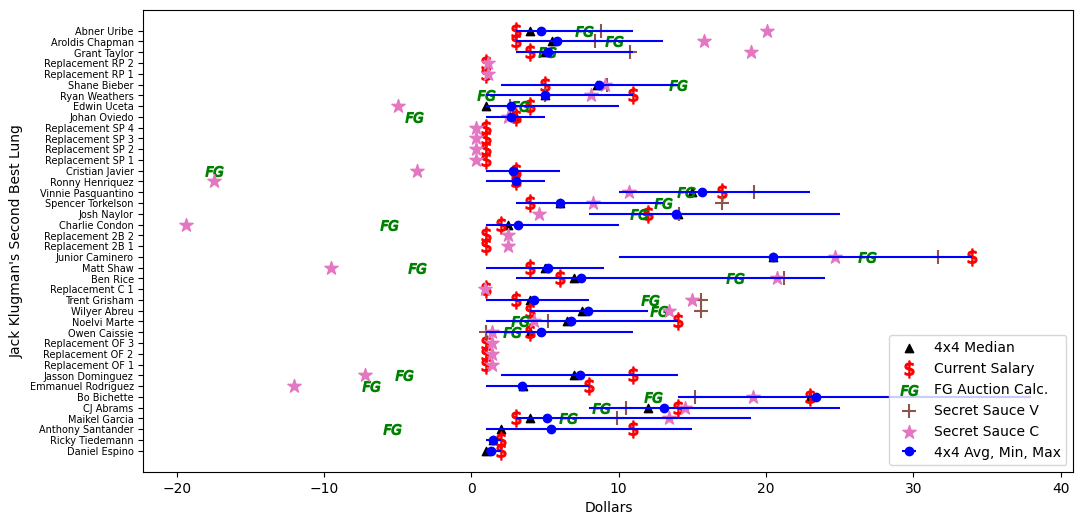

Carlos Pérez's K-Dance


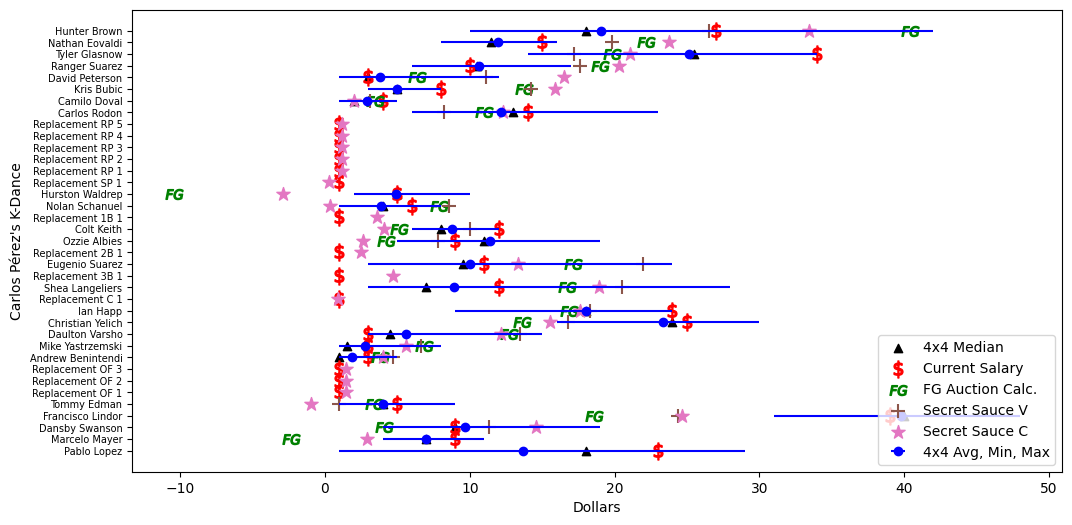

Hornswogglers


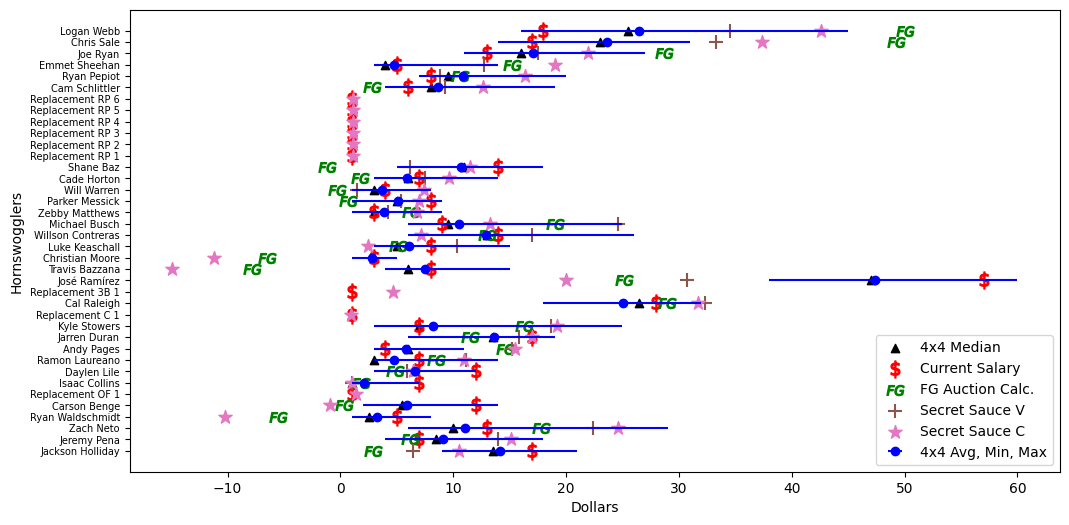

The Rime of Jamie Moyer


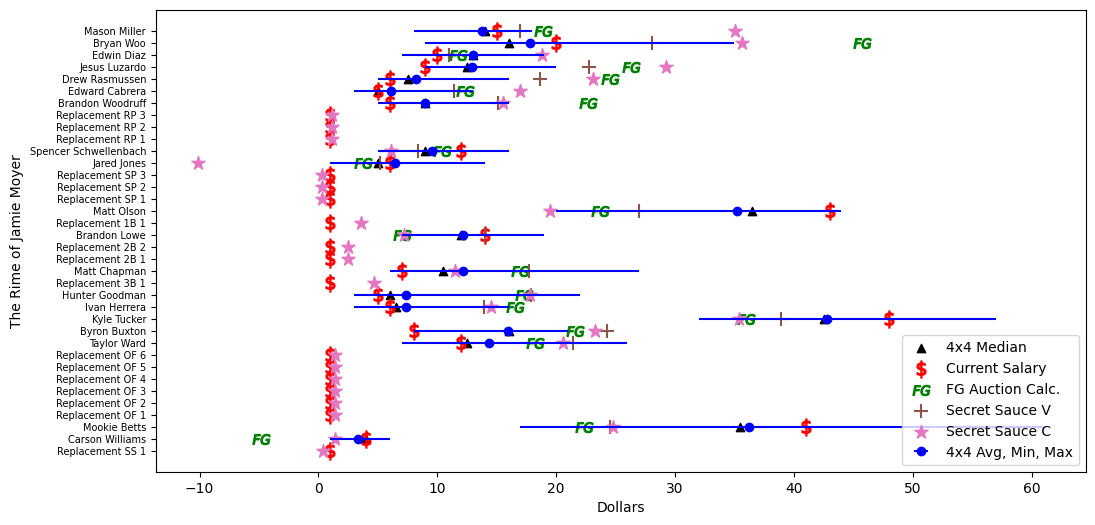

Chili Dog MVP


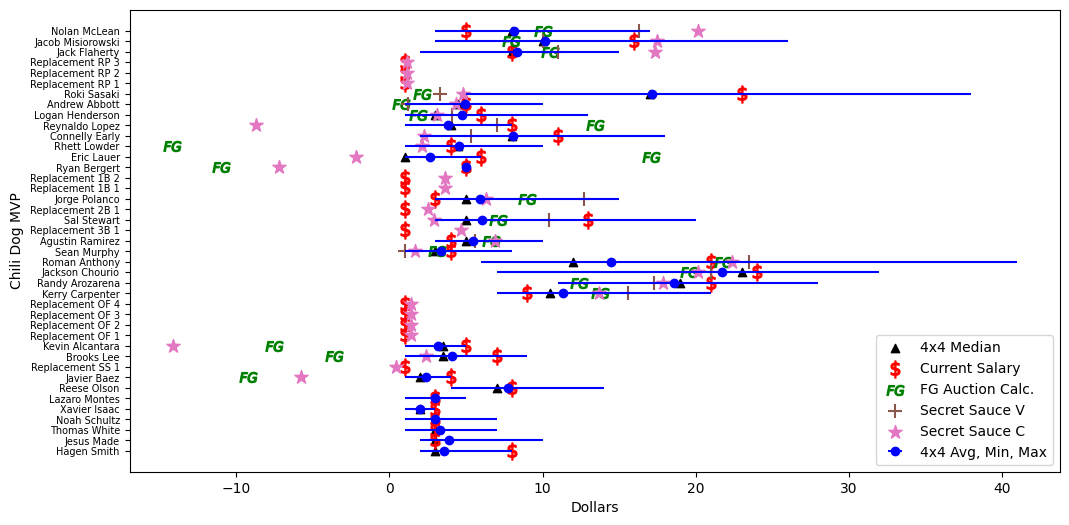

St. CGT VI


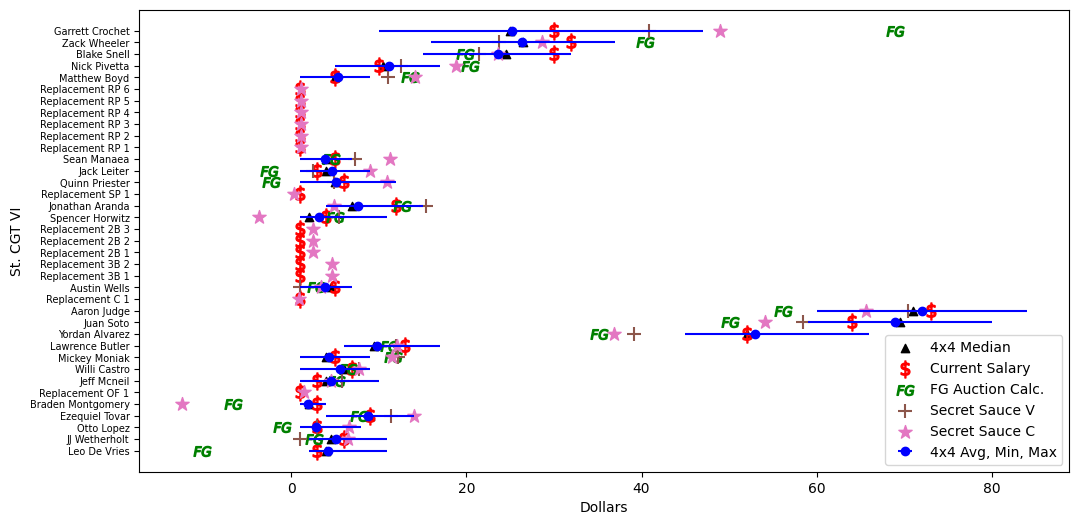

Yoshi Teddy Bear


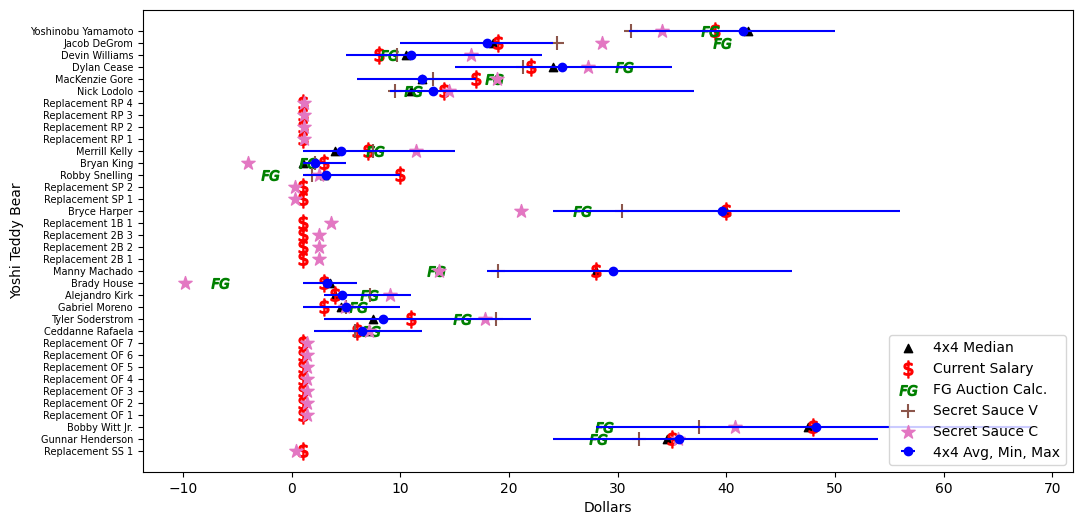

Largely Indistinguishables


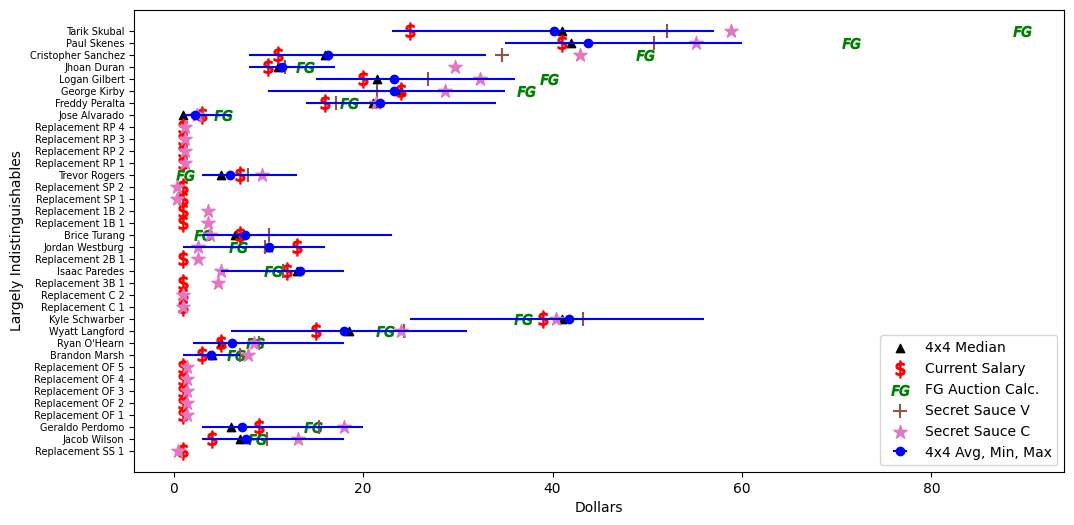

Broken Hamate Bonez 🦴


/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


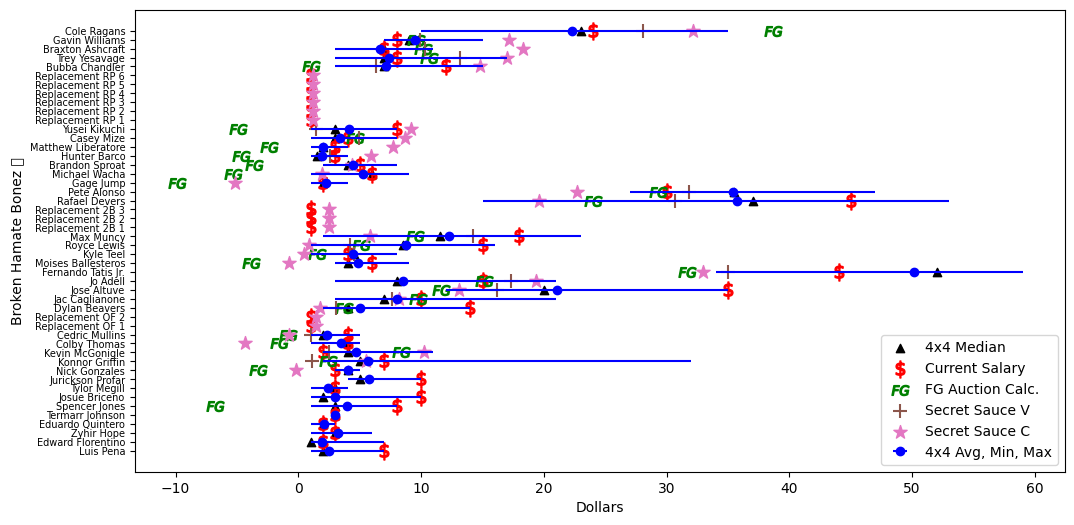

Smoak and Mirrors


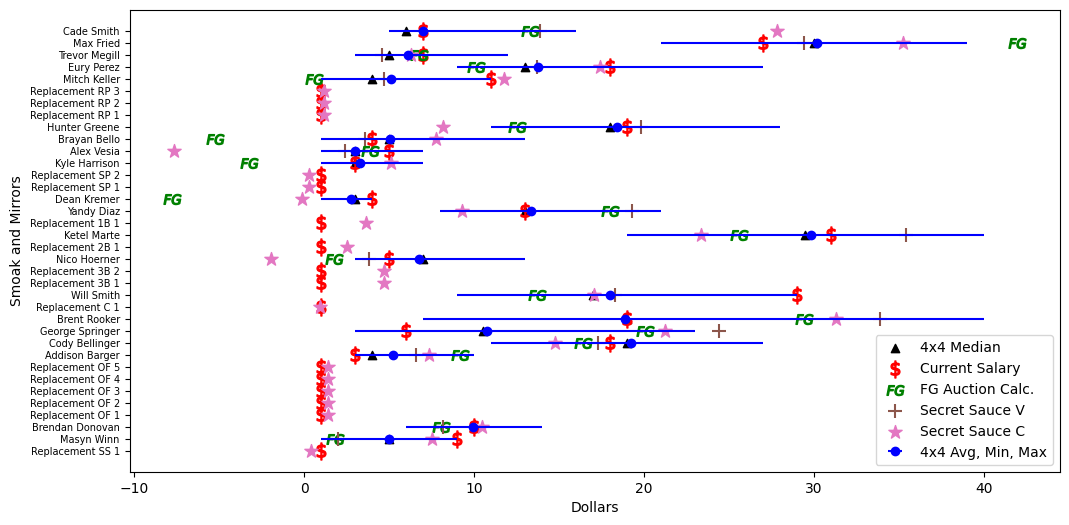

Roberto Big Piece and the 69ers


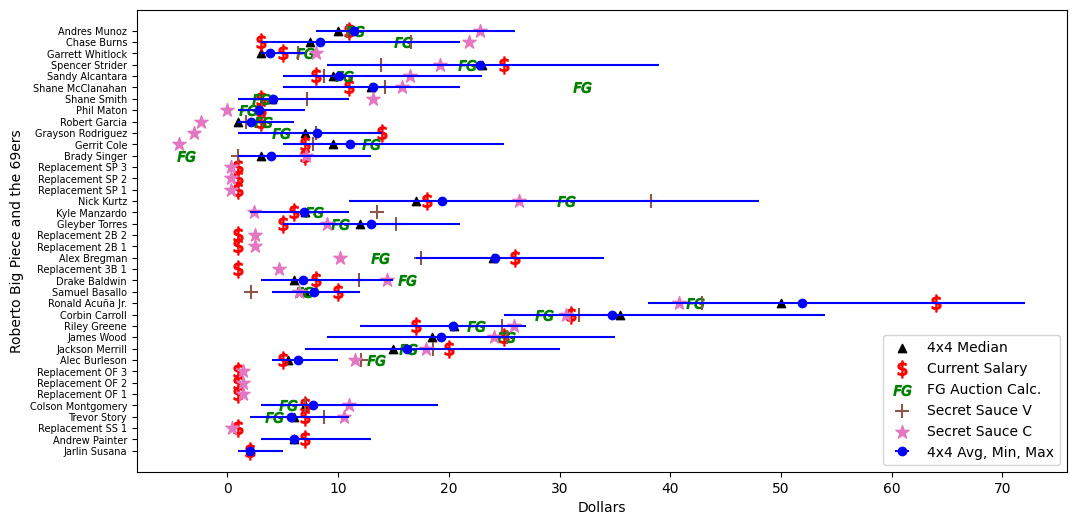

Roar from 34


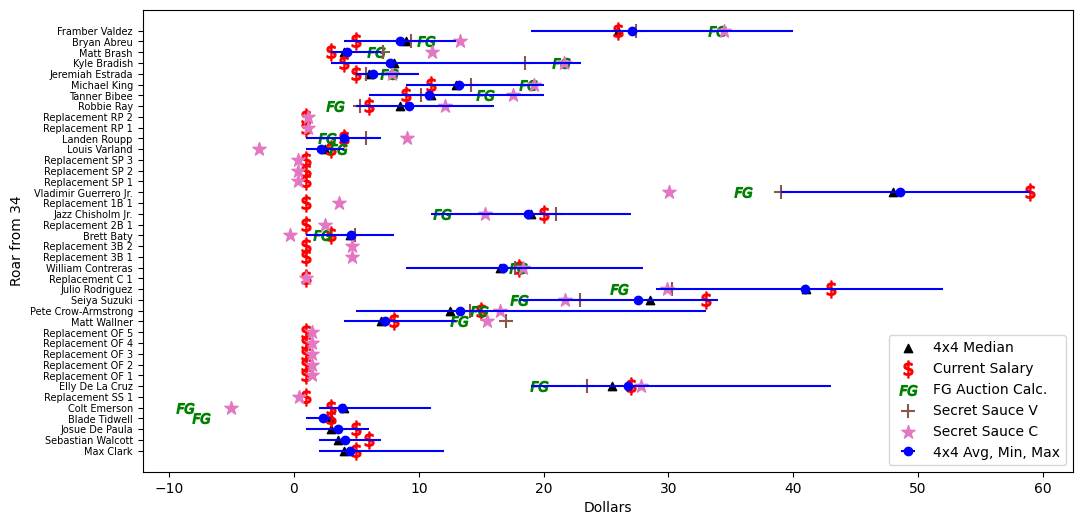

In [20]:
for team_id in All_Teams_df['TeamID'].unique():
    This_team_df = All_Teams_df[All_Teams_df['TeamID'] == team_id]
    team_name = All_Teams_df[All_Teams_df['TeamID'] == team_id]['Team Name'].unique()[0]
    print(team_name)
    quick_plotting_fn(This_team_df,team_name)

In [21]:
for team_id in All_Teams_df['TeamID'].unique():
    This_team_df = All_Teams_df[All_Teams_df['TeamID'] == team_id]
    team_name = All_Teams_df[All_Teams_df['TeamID'] == team_id]['Team Name'].unique()[0]
    #print(team_name)
    display(This_team_df.loc[This_team_df["Name"].str.startswith('Replacement', na=False)][['Team Name','Ottoneu Positions','G_mySGP_Team','IP_mySGP_Team']])
    #quick_plotting_fn(This_team_df,team_name)

,Team Name,Ottoneu Positions,G_mySGP_Team,IP_mySGP_Team
3,Jack Klugman's Second Best Lung,RP,NaN,62.78
4,Jack Klugman's Second Best Lung,RP,NaN,62.78
9,Jack Klugman's Second Best Lung,SP,NaN,97.29
10,Jack Klugman's Second Best Lung,SP,NaN,97.29
11,Jack Klugman's Second Best Lung,SP,NaN,97.29
12,Jack Klugman's Second Best Lung,SP,NaN,97.29
188,Jack Klugman's Second Best Lung,2B,133.97,NaN
189,Jack Klugman's Second Best Lung,2B,28.03,NaN
193,Jack Klugman's Second Best Lung,C,31.81,NaN
198,Jack Klugman's Second Best Lung,OF,112.00,NaN


,Team Name,Ottoneu Positions,G_mySGP_Team,IP_mySGP_Team
23,Carlos Pérez's K-Dance,RP,NaN,62.78
24,Carlos Pérez's K-Dance,RP,NaN,62.78
25,Carlos Pérez's K-Dance,RP,NaN,62.78
26,Carlos Pérez's K-Dance,RP,NaN,62.78
27,Carlos Pérez's K-Dance,RP,NaN,62.78
28,Carlos Pérez's K-Dance,SP,NaN,35.00
207,Carlos Pérez's K-Dance,1B,126.51,NaN
210,Carlos Pérez's K-Dance,2B,0.00,NaN
212,Carlos Pérez's K-Dance,3B,19.31,NaN
214,Carlos Pérez's K-Dance,C,32.68,NaN


,Team Name,Ottoneu Positions,G_mySGP_Team,IP_mySGP_Team
36,Hornswogglers,RP,NaN,62.78
37,Hornswogglers,RP,NaN,62.78
38,Hornswogglers,RP,NaN,62.78
39,Hornswogglers,RP,NaN,62.78
40,Hornswogglers,RP,NaN,62.78
41,Hornswogglers,RP,NaN,62.78
233,Hornswogglers,3B,8.80,NaN
235,Hornswogglers,C,8.30,NaN
242,Hornswogglers,OF,24.44,NaN


,Team Name,Ottoneu Positions,G_mySGP_Team,IP_mySGP_Team
54,The Rime of Jamie Moyer,RP,NaN,62.78
55,The Rime of Jamie Moyer,RP,NaN,62.78
56,The Rime of Jamie Moyer,RP,NaN,62.78
59,The Rime of Jamie Moyer,SP,NaN,97.29
60,The Rime of Jamie Moyer,SP,NaN,97.29
61,The Rime of Jamie Moyer,SP,NaN,27.59
249,The Rime of Jamie Moyer,1B,57.21,NaN
251,The Rime of Jamie Moyer,2B,133.97,NaN
252,The Rime of Jamie Moyer,2B,65.15,NaN
254,The Rime of Jamie Moyer,3B,12.24,NaN


,Team Name,Ottoneu Positions,G_mySGP_Team,IP_mySGP_Team
65,Chili Dog MVP,RP,NaN,62.78
66,Chili Dog MVP,RP,NaN,62.78
67,Chili Dog MVP,RP,NaN,62.78
269,Chili Dog MVP,1B,126.51,NaN
270,Chili Dog MVP,1B,126.51,NaN
272,Chili Dog MVP,2B,133.97,NaN
274,Chili Dog MVP,3B,114.38,NaN
281,Chili Dog MVP,OF,112.00,NaN
282,Chili Dog MVP,OF,112.00,NaN
283,Chili Dog MVP,OF,27.91,NaN


...

,Team Name,Ottoneu Positions,G_mySGP_Team,IP_mySGP_Team
114,Largely Indistinguishables,RP,NaN,62.78
115,Largely Indistinguishables,RP,NaN,62.78
116,Largely Indistinguishables,RP,NaN,62.78
117,Largely Indistinguishables,RP,NaN,62.78
119,Largely Indistinguishables,SP,NaN,0.00
120,Largely Indistinguishables,SP,NaN,0.00
331,Largely Indistinguishables,1B,126.51,NaN
332,Largely Indistinguishables,1B,126.51,NaN
335,Largely Indistinguishables,2B,0.00,NaN
337,Largely Indistinguishables,3B,62.95,NaN


,Team Name,Ottoneu Positions,G_mySGP_Team,IP_mySGP_Team
126,Broken Hamate Bonez 🦴,RP,NaN,62.78
127,Broken Hamate Bonez 🦴,RP,NaN,62.78
128,Broken Hamate Bonez 🦴,RP,NaN,62.78
129,Broken Hamate Bonez 🦴,RP,NaN,62.78
130,Broken Hamate Bonez 🦴,RP,NaN,62.78
131,Broken Hamate Bonez 🦴,RP,NaN,62.78
354,Broken Hamate Bonez 🦴,2B,133.97,NaN
355,Broken Hamate Bonez 🦴,2B,133.97,NaN
356,Broken Hamate Bonez 🦴,2B,56.07,NaN
366,Broken Hamate Bonez 🦴,OF,112.00,NaN


,Team Name,Ottoneu Positions,G_mySGP_Team,IP_mySGP_Team
144,Smoak and Mirrors,RP,NaN,62.78
145,Smoak and Mirrors,RP,NaN,62.78
146,Smoak and Mirrors,RP,NaN,62.78
151,Smoak and Mirrors,SP,NaN,97.29
152,Smoak and Mirrors,SP,NaN,97.29
374,Smoak and Mirrors,1B,126.51,NaN
376,Smoak and Mirrors,2B,133.97,NaN
378,Smoak and Mirrors,3B,128.71,NaN
379,Smoak and Mirrors,3B,85.20,NaN
381,Smoak and Mirrors,C,37.47,NaN


,Team Name,Ottoneu Positions,G_mySGP_Team,IP_mySGP_Team
166,Roberto Big Piece and the 69ers,SP,NaN,97.29
167,Roberto Big Piece and the 69ers,SP,NaN,18.70
168,Roberto Big Piece and the 69ers,SP,NaN,0.00
397,Roberto Big Piece and the 69ers,2B,60.06,NaN
398,Roberto Big Piece and the 69ers,2B,0.00,NaN
400,Roberto Big Piece and the 69ers,3B,10.35,NaN
409,Roberto Big Piece and the 69ers,OF,0.00,NaN
410,Roberto Big Piece and the 69ers,OF,0.00,NaN
411,Roberto Big Piece and the 69ers,OF,0.00,NaN
414,Roberto Big Piece and the 69ers,SS,0.00,NaN


,Team Name,Ottoneu Positions,G_mySGP_Team,IP_mySGP_Team
177,Roar from 34,RP,NaN,62.78
178,Roar from 34,RP,NaN,62.78
181,Roar from 34,SP,NaN,97.29
182,Roar from 34,SP,NaN,59.54
183,Roar from 34,SP,NaN,0.00
416,Roar from 34,1B,126.51,NaN
418,Roar from 34,2B,133.97,NaN
420,Roar from 34,3B,128.71,NaN
421,Roar from 34,3B,76.21,NaN
423,Roar from 34,C,14.82,NaN


In [22]:
for pos in All_Teams_df.loc[All_Teams_df["Name"].str.startswith('Replacement', na=False)]['Ottoneu Positions'].unique():
    This_pos_df = All_Teams_df[All_Teams_df['Ottoneu Positions'] == pos]
    #print(team_name)
    display(This_pos_df.loc[This_pos_df["Name"].str.startswith('Replacement', na=False)][['Team Name','Ottoneu Positions','G_mySGP_Team','IP_mySGP_Team']].reset_index(drop=True).sort_values(by=['G_mySGP_Team','IP_mySGP_Team'],ascending=False))
    #quick_plotting_fn(This_team_df,team_name)

,Team Name,Ottoneu Positions,G_mySGP_Team,IP_mySGP_Team
0,Jack Klugman's Second Best Lung,RP,NaN,62.78
1,Jack Klugman's Second Best Lung,RP,NaN,62.78
2,Carlos Pérez's K-Dance,RP,NaN,62.78
3,Carlos Pérez's K-Dance,RP,NaN,62.78
4,Carlos Pérez's K-Dance,RP,NaN,62.78
5,Carlos Pérez's K-Dance,RP,NaN,62.78
6,Carlos Pérez's K-Dance,RP,NaN,62.78
7,Hornswogglers,RP,NaN,62.78
8,Hornswogglers,RP,NaN,62.78
9,Hornswogglers,RP,NaN,62.78


,Team Name,Ottoneu Positions,G_mySGP_Team,IP_mySGP_Team
0,Jack Klugman's Second Best Lung,SP,NaN,97.29
1,Jack Klugman's Second Best Lung,SP,NaN,97.29
2,Jack Klugman's Second Best Lung,SP,NaN,97.29
3,Jack Klugman's Second Best Lung,SP,NaN,97.29
5,The Rime of Jamie Moyer,SP,NaN,97.29
6,The Rime of Jamie Moyer,SP,NaN,97.29
13,Smoak and Mirrors,SP,NaN,97.29
14,Smoak and Mirrors,SP,NaN,97.29
15,Roberto Big Piece and the 69ers,SP,NaN,97.29
18,Roar from 34,SP,NaN,97.29


,Team Name,Ottoneu Positions,G_mySGP_Team,IP_mySGP_Team
0,Jack Klugman's Second Best Lung,2B,133.97,NaN
3,The Rime of Jamie Moyer,2B,133.97,NaN
5,Chili Dog MVP,2B,133.97,NaN
6,St. CGT VI,2B,133.97,NaN
7,St. CGT VI,2B,133.97,NaN
9,Yoshi Teddy Bear,2B,133.97,NaN
13,Broken Hamate Bonez 🦴,2B,133.97,NaN
14,Broken Hamate Bonez 🦴,2B,133.97,NaN
16,Smoak and Mirrors,2B,133.97,NaN
19,Roar from 34,2B,133.97,NaN


,Team Name,Ottoneu Positions,G_mySGP_Team,IP_mySGP_Team
4,Largely Indistinguishables,C,102.20,NaN
5,Largely Indistinguishables,C,59.80,NaN
3,St. CGT VI,C,45.24,NaN
6,Smoak and Mirrors,C,37.47,NaN
1,Carlos Pérez's K-Dance,C,32.68,NaN
0,Jack Klugman's Second Best Lung,C,31.81,NaN
7,Roar from 34,C,14.82,NaN
2,Hornswogglers,C,8.30,NaN


,Team Name,Ottoneu Positions,G_mySGP_Team,IP_mySGP_Team
0,Jack Klugman's Second Best Lung,OF,112.00,NaN
1,Jack Klugman's Second Best Lung,OF,112.00,NaN
2,Jack Klugman's Second Best Lung,OF,112.00,NaN
3,Carlos Pérez's K-Dance,OF,112.00,NaN
7,The Rime of Jamie Moyer,OF,112.00,NaN
8,The Rime of Jamie Moyer,OF,112.00,NaN
9,The Rime of Jamie Moyer,OF,112.00,NaN
13,Chili Dog MVP,OF,112.00,NaN
14,Chili Dog MVP,OF,112.00,NaN
18,Yoshi Teddy Bear,OF,112.00,NaN


,Team Name,Ottoneu Positions,G_mySGP_Team,IP_mySGP_Team
0,Carlos Pérez's K-Dance,1B,126.51,NaN
2,Chili Dog MVP,1B,126.51,NaN
3,Chili Dog MVP,1B,126.51,NaN
4,Yoshi Teddy Bear,1B,126.51,NaN
5,Largely Indistinguishables,1B,126.51,NaN
6,Largely Indistinguishables,1B,126.51,NaN
7,Smoak and Mirrors,1B,126.51,NaN
8,Roar from 34,1B,126.51,NaN
1,The Rime of Jamie Moyer,1B,57.21,NaN


,Team Name,Ottoneu Positions,G_mySGP_Team,IP_mySGP_Team
4,St. CGT VI,3B,128.71,NaN
5,St. CGT VI,3B,128.71,NaN
7,Smoak and Mirrors,3B,128.71,NaN
10,Roar from 34,3B,128.71,NaN
3,Chili Dog MVP,3B,114.38,NaN
8,Smoak and Mirrors,3B,85.20,NaN
11,Roar from 34,3B,76.21,NaN
6,Largely Indistinguishables,3B,62.95,NaN
0,Carlos Pérez's K-Dance,3B,19.31,NaN
2,The Rime of Jamie Moyer,3B,12.24,NaN


,Team Name,Ottoneu Positions,G_mySGP_Team,IP_mySGP_Team
1,Chili Dog MVP,SS,92.54,NaN
6,Roar from 34,SS,10.45,NaN
0,The Rime of Jamie Moyer,SS,0.00,NaN
2,Yoshi Teddy Bear,SS,0.00,NaN
3,Largely Indistinguishables,SS,0.00,NaN
4,Smoak and Mirrors,SS,0.00,NaN
5,Roberto Big Piece and the 69ers,SS,0.00,NaN


In [23]:
%%capture cap0 --no-stderr
for pos in All_Teams_df.loc[All_Teams_df["Name"].str.startswith('Replacement', na=False)]['Ottoneu Positions'].unique():
    This_pos_df = All_Teams_df[All_Teams_df['Ottoneu Positions'] == pos]
    print('+++++++++++++++++++++++++++++++++++++++++++++++++++')
    print('+++++++++++++++++++++++++++++++++++++++++++++++++++\n')
    print(pos,'\n')
    print('+++++++++++++++++++++++++++++++++++++++++++++++++++')
    Repl_df = This_pos_df.loc[This_pos_df["Name"].str.startswith('Replacement', na=False)][['Team Name','Ottoneu Positions','G_mySGP_Team','IP_mySGP_Team']].reset_index(drop=True).sort_values(by=['G_mySGP_Team','IP_mySGP_Team'],ascending=False)
    print('Est. Demand:', Repl_df.shape[0])
    print('My Need:', Repl_df[Repl_df['Team Name'] == 'Largely Indistinguishables'].shape[0])
    #quick_plotting_fn(This_team_df,team_name)

In [24]:
with open('Team_Est_Demand.txt', 'w') as f:
    f.write(cap0.stdout)

In [25]:
%%capture cap --no-stderr
for pos in ['SP','Util']:
    This_Pos_Stat_Cats = Pitching_value_columns if pos in Pitching_Pos else Batting_value_columns
    print('+++++++++++++++++++++++++++++++++++++++++++++++++++')
    print('+++++++++++++++++++++++++++++++++++++++++++++++++++\n\n')
    print(pos,'\n\n')
    print('+++++++++++++++++++++++++++++++++++++++++++++++++++')
    print('+++++++++++++++++++++++++++++++++++++++++++++++++++')
    for stat_cat, stat_cols in This_Pos_Stat_Cats.items():
        # if Stat in bugged_cols:
        #     continue
        # print(pos)
        # print(stat_cat)
        # print(All_teams_replacement_level[stat_cat])
        # fig1 = plt.figure(figsize=(10,5))
        # ax1 = fig1.add_subplot(111)
        # sns.histplot(All_teams_replacement_level,x='Team Name',weights=stat_cat,hue='Ottoneu Positions', multiple='stack',ax=ax1)
        # ax1.axhline(y=Target_Stats_df[stat_cat])
        # plt.tight_layout()
        # plt.show()

        print('+++++++++++++++++++++++++++++++++++++++++++++++++++\n')
        print(stat_cat,'\n')
        print('+++++++++++++++++++++++++++++++++++++++++++++++++++')
        
        

        for stat in stat_cols:
            print('---------------------------------------------------')
            print(stat)
            print('---------------------------------------------------')
            # fig2 = plt.figure(figsize=(10,5))
            # ax2 = fig2.add_subplot(111)
            my_team_currently = 0.
            if stat in Team_Rate_Cols:
                # sns.histplot(All_Teams_df[All_Teams_df['Repl_Pos_mySGP'].isin(Pitching_Pos if pos in Pitching_Pos else Hitting_Pos) if stat not in ['TOTAL_SGP_Val_mySGP','Salary'] else [True]*len(All_Teams_df)].dropna(subset=stat).groupby('Team Name')[stat].mean().sort_values().reset_index(),y='Team Name',weights=stat,color='darkorange',ax=ax2)
                # sns.scatterplot(All_Teams_df[All_Teams_df['Repl_Pos_mySGP'].isin(Pitching_Pos if pos in Pitching_Pos else Hitting_Pos) if stat not in ['TOTAL_SGP_Val_mySGP','Salary'] else [True]*len(All_Teams_df)].dropna(subset=stat.replace('_','_pos_')),y='Team Name',x=stat.replace('_','_pos_'),hue='Repl_Pos_mySGP',ax=ax2)
                team_mean_df = All_Teams_df[All_Teams_df['Repl_Pos_mySGP'].isin(Pitching_Pos if pos in Pitching_Pos else Hitting_Pos) if stat not in ['TOTAL_SGP_Val_mySGP','Salary'] else [True]*len(All_Teams_df)].dropna(subset=stat).groupby('Team Name')[stat].mean().sort_values().reset_index()
                my_team_currently = team_mean_df[team_mean_df['Team Name'] == 'Largely Indistinguishables'][stat].unique()[0]
                team_mean_df['rank'] = team_mean_df[stat].rank(ascending=False)
                #display(team_mean_df)
                my_team_rank = team_mean_df[team_mean_df['Team Name'] == 'Largely Indistinguishables']['rank'].unique()[0]
            else:
                #sns.histplot(All_Teams_df[All_Teams_df['Repl_Pos_mySGP'].isin(Pitching_Pos if pos in Pitching_Pos else Hitting_Pos) if stat not in ['TOTAL_SGP_Val_mySGP','Salary'] else [True]*len(All_Teams_df)].dropna(subset=stat).sort_values(stat),y='Team Name',weights=stat,hue='Repl_Pos_mySGP', multiple='stack',ax=ax2)
                team_sum_df = All_Teams_df[All_Teams_df['Repl_Pos_mySGP'].isin(Pitching_Pos if pos in Pitching_Pos else Hitting_Pos) if stat not in ['TOTAL_SGP_Val_mySGP','Salary'] else [True]*len(All_Teams_df)].dropna(subset=stat).groupby('Team Name')[stat].sum().sort_values().reset_index()
                my_team_currently = team_sum_df[team_sum_df['Team Name'] == 'Largely Indistinguishables'][stat].unique()[0]
                team_sum_df['rank'] = team_sum_df[stat].rank(ascending=False)
                #display(team_sum_df)
                my_team_rank = team_sum_df[team_sum_df['Team Name'] == 'Largely Indistinguishables']['rank'].unique()[0]
            # ax2.tick_params(axis='x', labelrotation=45)
            # ax2.set_xlabel(stat)
            # ax2.set_ylabel('Team Name')
            if (stat in Target_Stats_df[Target_Stats_df['Hitter Pitcher'] == ('Pitcher' if pos in Pitching_Pos else 'Hitter')].dropna(axis=1).columns):
                #ax2.axvline(x=Target_Stats_df[Target_Stats_df['Hitter Pitcher'] == ('Pitcher' if pos in Pitching_Pos else 'Hitter')][stat].unique()[0],label='Target')
                print(f'Target {stat}:', Target_Stats_df[Target_Stats_df['Hitter Pitcher'] == ('Pitcher' if pos in Pitching_Pos else 'Hitter')][stat].unique()[0])
                print('Rank with Replacement Players:',my_team_rank)
                print('Largely Indistinguishables with Replacement Players:',my_team_currently)
                print(f'Delta:', my_team_currently - Target_Stats_df[Target_Stats_df['Hitter Pitcher'] == ('Pitcher' if pos in Pitching_Pos else 'Hitter')][stat].unique()[0])
            else:
                print(Target_Stats_df[Target_Stats_df['Hitter Pitcher'] == ('Pitcher' if pos in Pitching_Pos else 'Hitter')].dropna(axis=1).columns)
            # plt.tight_layout()
            # plt.show()
            #sns.histplot(All_teams_replacement_level.dropna(subset=stat),y=stat,hue=)

In [26]:
with open('Team_Ranks_with_Replacement.txt', 'w') as f:
    f.write(cap.stdout)

,Team Name,TOTAL_SGP_Val_mySGP,rank
0,Chili Dog MVP,151.79,12.0
1,Jack Klugman's Second Best Lung,164.07,11.0
2,Smoak and Mirrors,280.28,10.0
3,Broken Hamate Bonez 🦴,283.77,9.0
4,Carlos Pérez's K-Dance,299.86,8.0
5,Yoshi Teddy Bear,316.51,7.0
6,Roar from 34,340.32,6.0
7,Hornswogglers,364.00,5.0
8,Roberto Big Piece and the 69ers,370.93,4.0
9,The Rime of Jamie Moyer,372.94,3.0


Target TOTAL_SGP_Val_mySGP: 500.0
Largely Indistinguishables with Replacement Players: 432.85192297602134
Delta: -67.14807702397866


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_58647/3066415080.py:46: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


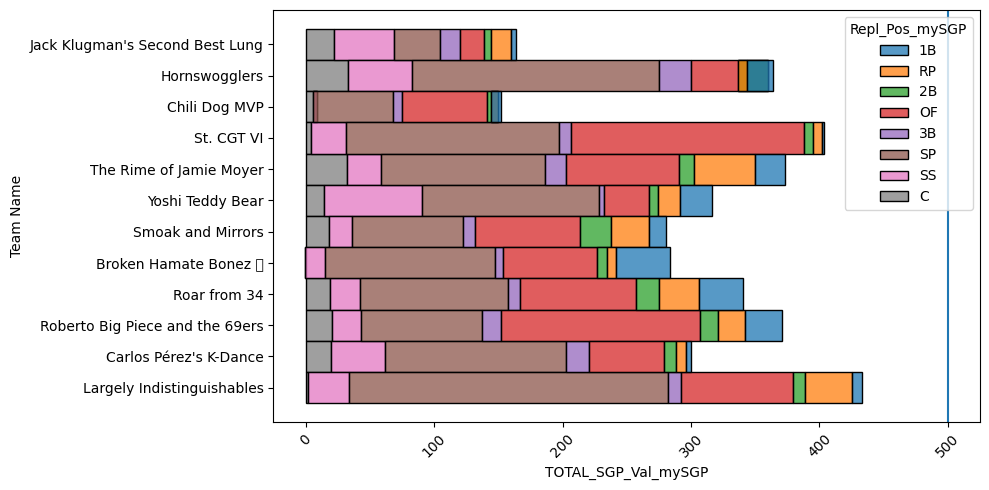

,Team Name,IP_mySGP_Team,rank
0,Jack Klugman's Second Best Lung,1250.19,12.0
1,Chili Dog MVP,1412.11,11.0
2,Carlos Pérez's K-Dance,1500.00,10.0
3,Broken Hamate Bonez 🦴,1500.00,6.5
4,Hornswogglers,1500.00,6.5
5,Largely Indistinguishables,1500.00,6.5
6,Roberto Big Piece and the 69ers,1500.00,6.5
7,The Rime of Jamie Moyer,1500.00,6.5
8,Yoshi Teddy Bear,1500.00,6.5
9,Roar from 34,1500.00,2.5


Target IP_mySGP_Team: 1500.0
Largely Indistinguishables with Replacement Players: 1499.9999999999998
Delta: -2.2737367544323206e-13


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_58647/3066415080.py:46: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


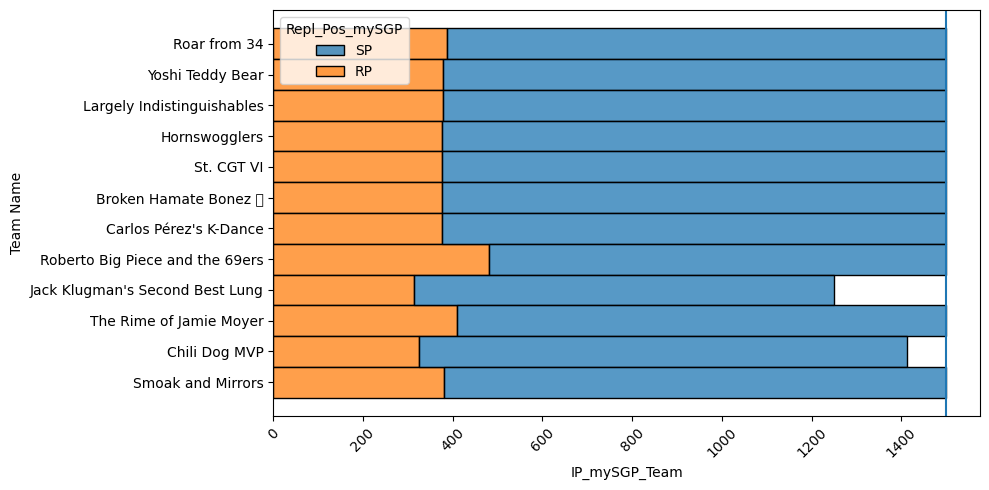

,Team Name,IP_FGAV_Team,rank
0,Jack Klugman's Second Best Lung,1285.71,12.0
1,Chili Dog MVP,1389.34,11.0
2,Hornswogglers,1506.91,10.0
3,Smoak and Mirrors,1519.74,9.0
4,Largely Indistinguishables,1521.45,8.0
5,Yoshi Teddy Bear,1523.46,7.0
6,St. CGT VI,1524.32,6.0
7,Broken Hamate Bonez 🦴,1525.79,5.0
8,Roar from 34,1527.38,4.0
9,Carlos Pérez's K-Dance,1533.89,3.0


Target IP_FGAV_Team: 1500.0
Largely Indistinguishables with Replacement Players: 1521.4511808195257
Delta: 21.45118081952569


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_58647/3066415080.py:46: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


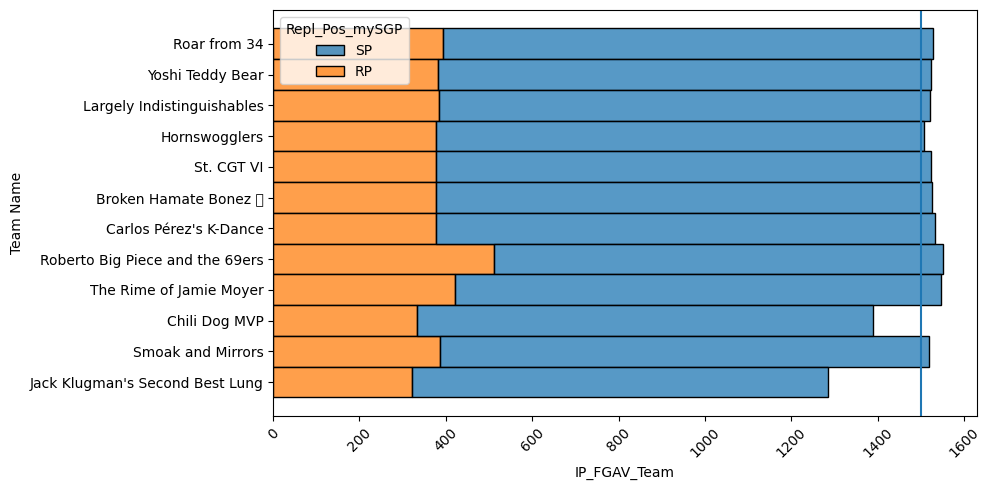

,Team Name,Salary,rank
0,Jack Klugman's Second Best Lung,229.0,12.0
1,Chili Dog MVP,255.0,11.0
2,Smoak and Mirrors,264.0,10.0
3,Largely Indistinguishables,282.0,9.0
4,The Rime of Jamie Moyer,294.0,8.0
5,Carlos Pérez's K-Dance,326.0,7.0
6,Yoshi Teddy Bear,335.0,6.0
7,Roar from 34,340.0,5.0
8,Hornswogglers,347.0,4.0
9,Roberto Big Piece and the 69ers,368.0,3.0


Target Salary: 380.0
Largely Indistinguishables with Replacement Players: 282.0
Delta: -98.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_58647/3066415080.py:46: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


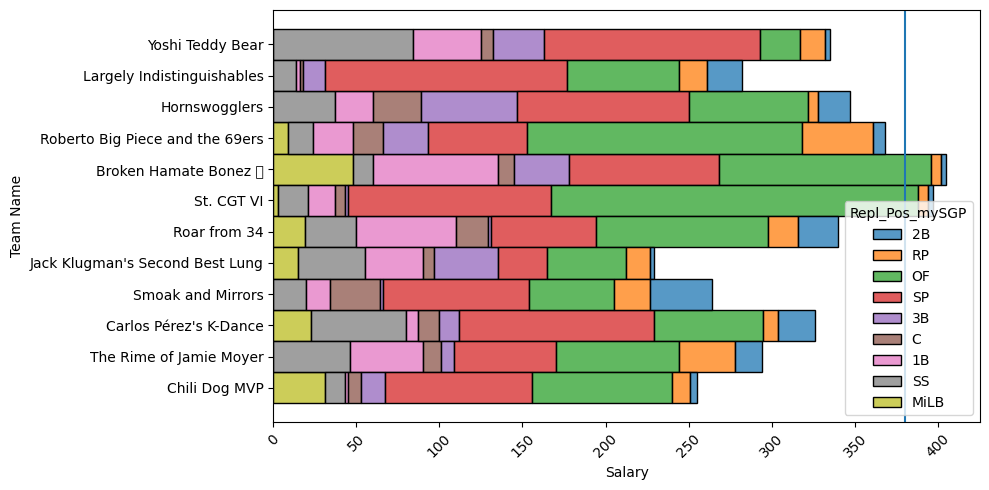

,Team Name,SO_mySGP_Team,rank
0,Jack Klugman's Second Best Lung,1267.87,12.0
1,Chili Dog MVP,1422.27,11.0
2,Smoak and Mirrors,1522.31,10.0
3,Roberto Big Piece and the 69ers,1544.85,9.0
4,Carlos Pérez's K-Dance,1550.18,8.0
5,Roar from 34,1554.11,7.0
6,Broken Hamate Bonez 🦴,1564.84,6.0
7,The Rime of Jamie Moyer,1593.36,5.0
8,Yoshi Teddy Bear,1607.63,4.0
9,Hornswogglers,1630.57,3.0


Target SO_mySGP_Team: 1634.481105636577
Largely Indistinguishables with Replacement Players: 1663.1677031839495
Delta: 28.686597547372457


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_58647/3066415080.py:46: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


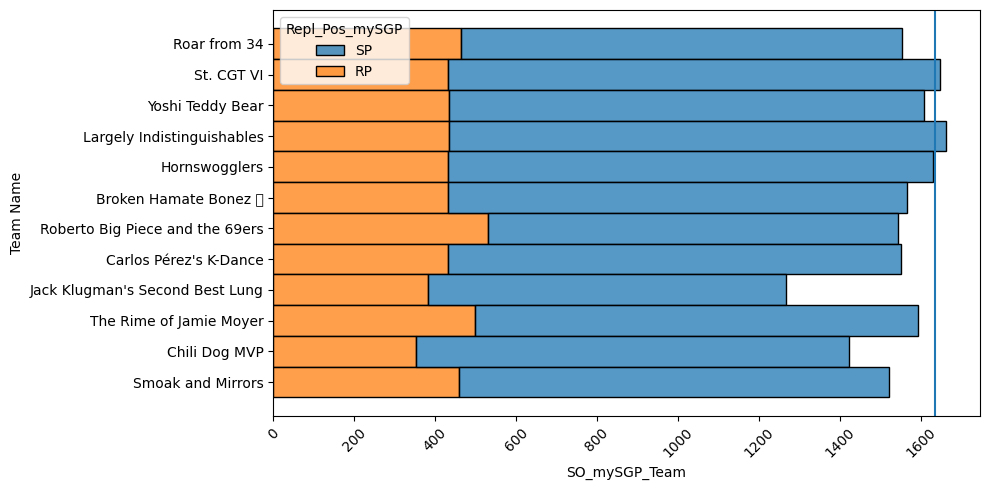

,Team Name,SO_SGP_Val_mySGP_Team,rank
0,Jack Klugman's Second Best Lung,27.93,12.0
1,Chili Dog MVP,98.06,11.0
2,Smoak and Mirrors,110.27,10.0
3,The Rime of Jamie Moyer,139.57,9.0
4,Roar from 34,144.70,8.0
5,Carlos Pérez's K-Dance,149.24,7.0
6,Yoshi Teddy Bear,158.22,6.0
7,Roberto Big Piece and the 69ers,161.42,5.0
8,Broken Hamate Bonez 🦴,163.05,4.0
9,Hornswogglers,180.41,3.0


Target SO_SGP_Val_mySGP_Team: 200.0
Largely Indistinguishables with Replacement Players: 209.54400557591617
Delta: 9.544005575916174


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_58647/3066415080.py:46: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


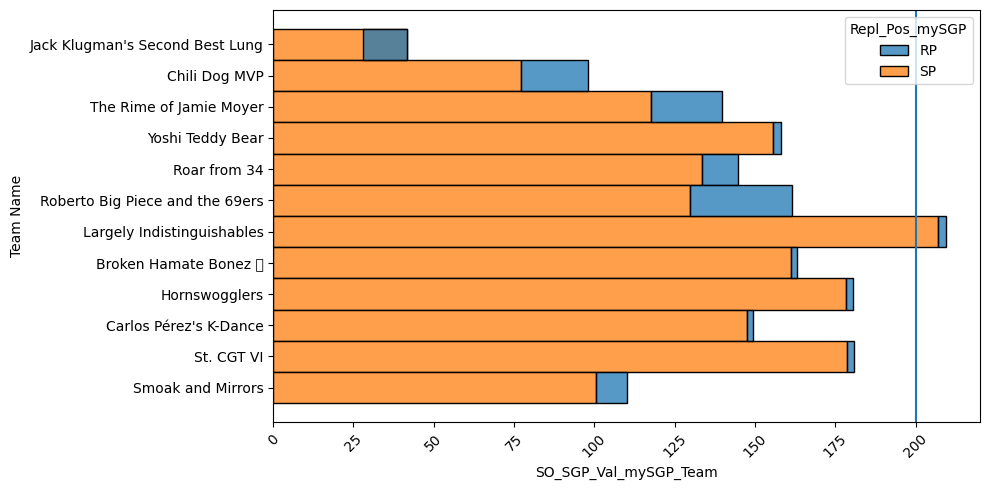

,Team Name,HR9_Team,rank
0,Jack Klugman's Second Best Lung,0.64,12.0
1,Carlos Pérez's K-Dance,0.78,11.0
2,Largely Indistinguishables,0.79,10.0
3,The Rime of Jamie Moyer,0.79,9.0
4,Smoak and Mirrors,0.82,8.0
5,Broken Hamate Bonez 🦴,0.83,7.0
6,Hornswogglers,0.84,6.0
7,Roar from 34,0.85,5.0
8,St. CGT VI,0.87,4.0
9,Yoshi Teddy Bear,0.88,3.0


Target HR9_Team: 0.9894539115424572
Largely Indistinguishables with Replacement Players: 0.7859903360937764
Delta: -0.20346357544868077


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_58647/3066415080.py:46: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


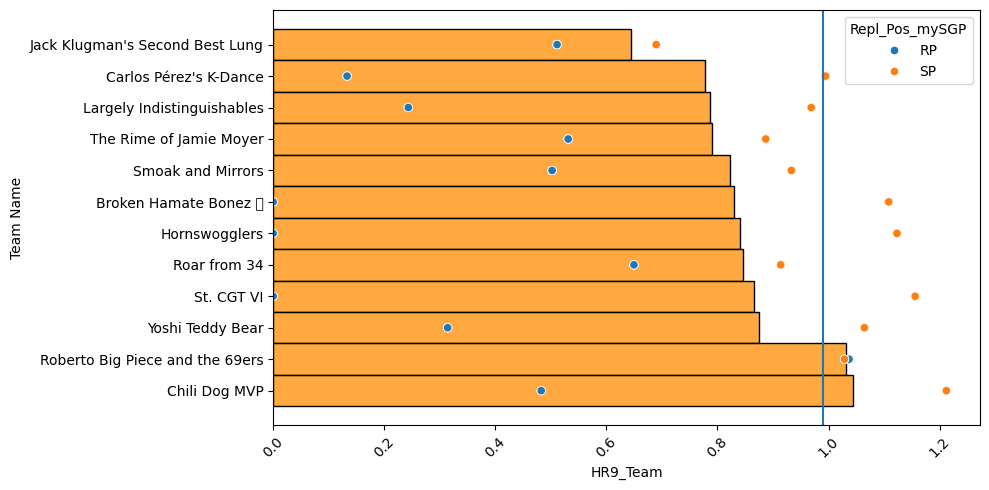

,Team Name,HR9_SGP_Val_mySGP_Team,rank
0,Chili Dog MVP,-72.53,12.0
1,Roberto Big Piece and the 69ers,-55.38,11.0
2,Smoak and Mirrors,79.29,10.0
3,Jack Klugman's Second Best Lung,85.31,9.0
4,The Rime of Jamie Moyer,118.00,8.0
5,St. CGT VI,135.84,7.0
6,Yoshi Teddy Bear,161.26,6.0
7,Hornswogglers,184.39,5.0
8,Roar from 34,199.77,4.0
9,Broken Hamate Bonez 🦴,211.07,3.0


Target HR9_SGP_Val_mySGP_Team: 200.0
Largely Indistinguishables with Replacement Players: 553.3241193626569
Delta: 353.3241193626569


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_58647/3066415080.py:46: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


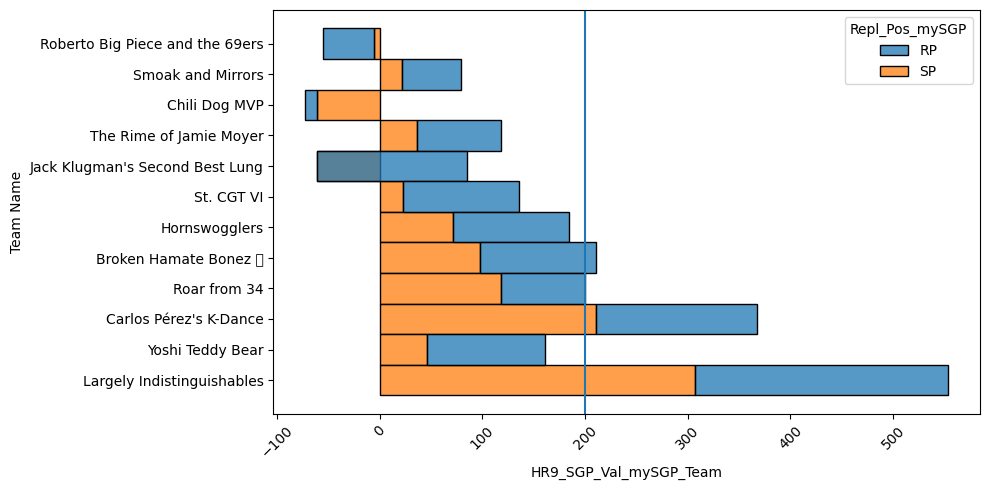

,Team Name,ERA_Team,rank
0,Largely Indistinguishables,3.22,12.0
1,Hornswogglers,3.60,11.0
2,St. CGT VI,3.61,10.0
3,The Rime of Jamie Moyer,3.63,9.0
4,Yoshi Teddy Bear,3.69,8.0
5,Carlos Pérez's K-Dance,3.70,7.0
6,Roar from 34,3.75,6.0
7,Broken Hamate Bonez 🦴,3.81,5.0
8,Smoak and Mirrors,3.86,4.0
9,Roberto Big Piece and the 69ers,3.87,3.0


Target ERA_Team: 3.3765511551106724
Largely Indistinguishables with Replacement Players: 3.222948596819544
Delta: -0.15360255829112823


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_58647/3066415080.py:46: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


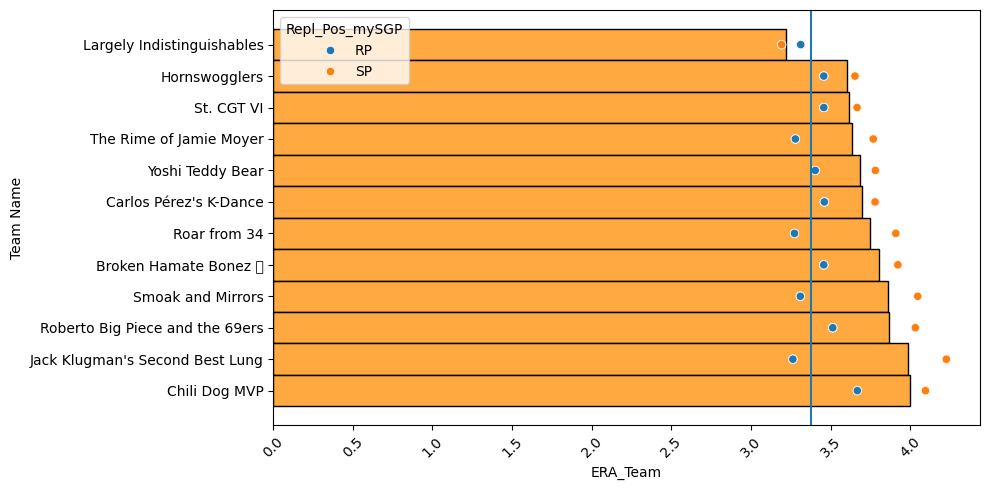

,Team Name,ERA_SGP_Val_mySGP_Team,rank
0,Chili Dog MVP,53.07,12.0
1,Roberto Big Piece and the 69ers,73.58,11.0
2,Jack Klugman's Second Best Lung,86.11,10.0
3,Broken Hamate Bonez 🦴,112.94,9.0
4,Smoak and Mirrors,131.52,8.0
5,Carlos Pérez's K-Dance,140.58,7.0
6,Yoshi Teddy Bear,157.47,6.0
7,Roar from 34,161.98,5.0
8,St. CGT VI,171.00,4.0
9,Hornswogglers,171.43,3.0


Target ERA_SGP_Val_mySGP_Team: 200.0
Largely Indistinguishables with Replacement Players: 307.03078890802675
Delta: 107.03078890802675


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_58647/3066415080.py:46: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


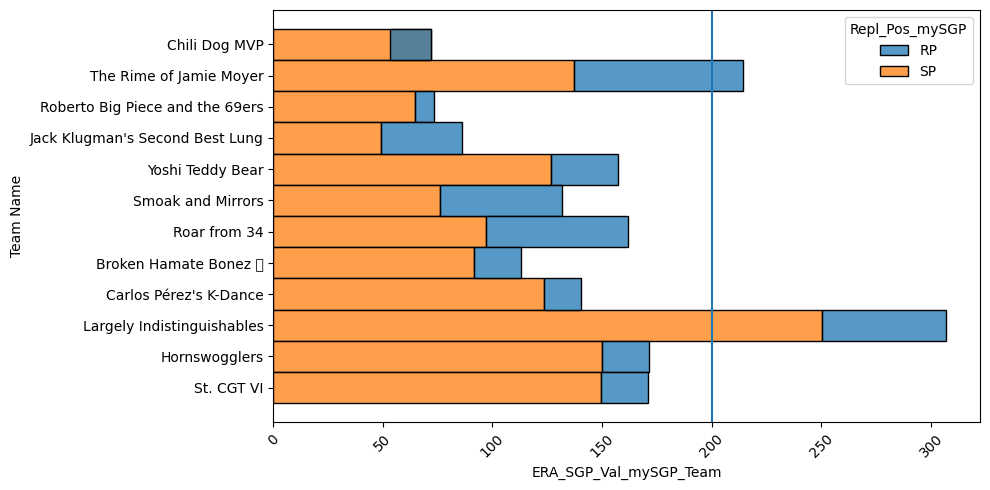

,Team Name,WHIP_Team,rank
0,Largely Indistinguishables,1.12,12.0
1,The Rime of Jamie Moyer,1.18,11.0
2,St. CGT VI,1.18,10.0
3,Hornswogglers,1.18,9.0
4,Yoshi Teddy Bear,1.20,8.0
5,Carlos Pérez's K-Dance,1.23,7.0
6,Roberto Big Piece and the 69ers,1.23,6.0
7,Smoak and Mirrors,1.24,5.0
8,Roar from 34,1.24,4.0
9,Broken Hamate Bonez 🦴,1.25,3.0


Target WHIP_Team: 1.128832633601803
Largely Indistinguishables with Replacement Players: 1.1157750605227783
Delta: -0.013057573079024776


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_58647/3066415080.py:46: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


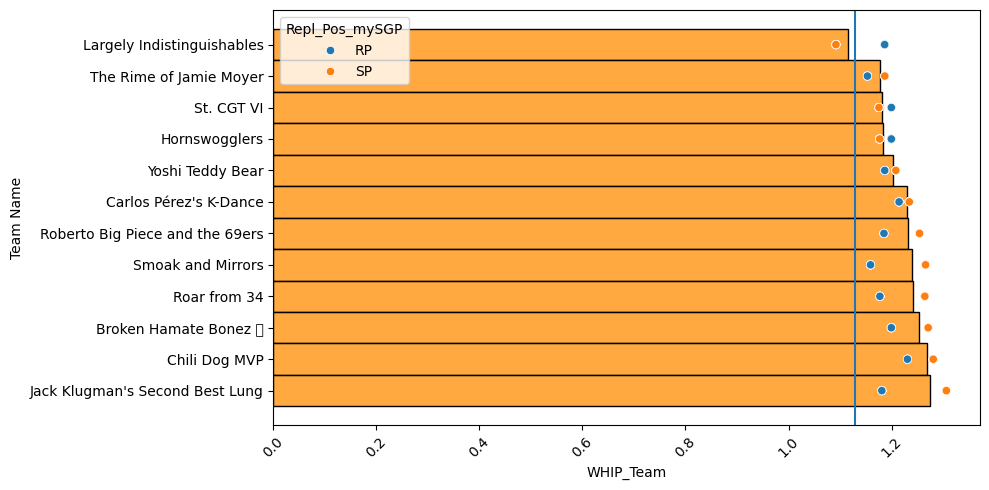

,Team Name,WHIP_SGP_Val_mySGP_Team,rank
0,Chili Dog MVP,70.27,12.0
1,Jack Klugman's Second Best Lung,79.76,11.0
2,Broken Hamate Bonez 🦴,97.89,10.0
3,Carlos Pérez's K-Dance,112.00,9.0
4,Roar from 34,121.00,8.0
5,Roberto Big Piece and the 69ers,124.03,7.0
6,Smoak and Mirrors,165.40,6.0
7,Yoshi Teddy Bear,183.50,5.0
8,Hornswogglers,205.56,4.0
9,St. CGT VI,210.35,3.0


Target WHIP_SGP_Val_mySGP_Team: 200.0
Largely Indistinguishables with Replacement Players: 304.8978197443655
Delta: 104.8978197443655


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_58647/3066415080.py:46: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


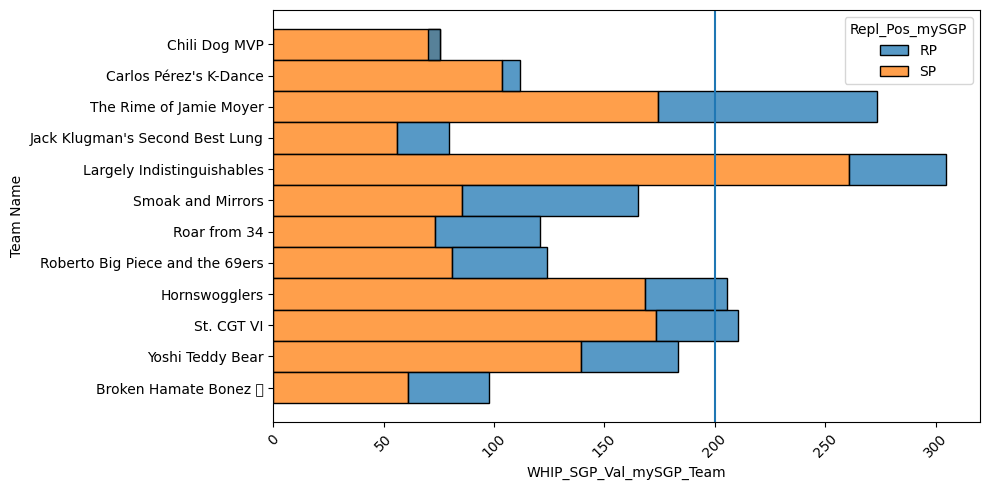

,Team Name,TOTAL_SGP_Val_mySGP,rank
0,Chili Dog MVP,151.79,12.0
1,Jack Klugman's Second Best Lung,164.07,11.0
2,Smoak and Mirrors,280.28,10.0
3,Broken Hamate Bonez 🦴,283.77,9.0
4,Carlos Pérez's K-Dance,299.86,8.0
5,Yoshi Teddy Bear,316.51,7.0
6,Roar from 34,340.32,6.0
7,Hornswogglers,364.00,5.0
8,Roberto Big Piece and the 69ers,370.93,4.0
9,The Rime of Jamie Moyer,372.94,3.0


Target TOTAL_SGP_Val_mySGP: 500.0
Largely Indistinguishables with Replacement Players: 432.85192297602134
Delta: -67.14807702397866


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_58647/3066415080.py:46: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


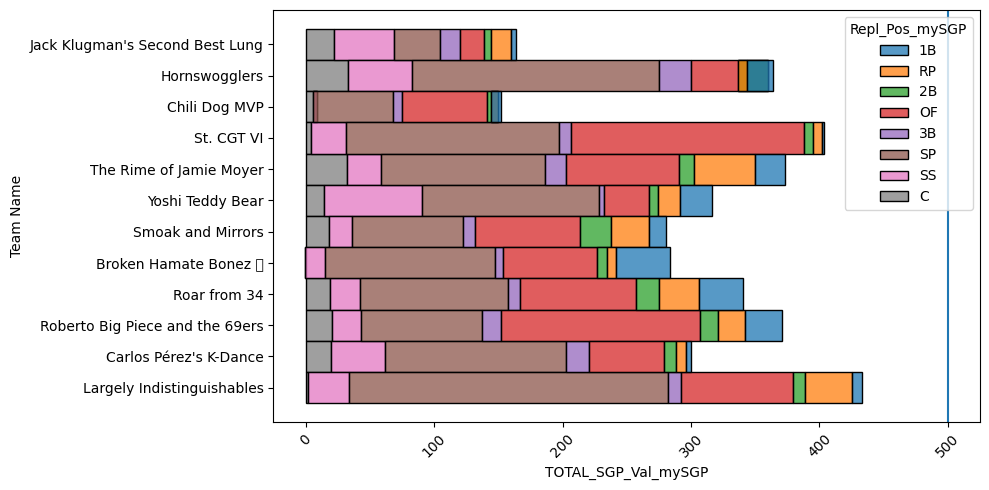

,Team Name,G_mySGP_Team,rank
0,Broken Hamate Bonez 🦴,1944.0,6.5
1,Carlos Pérez's K-Dance,1944.0,6.5
2,Chili Dog MVP,1944.0,6.5
3,Hornswogglers,1944.0,6.5
4,Jack Klugman's Second Best Lung,1944.0,6.5
5,Largely Indistinguishables,1944.0,6.5
6,Roar from 34,1944.0,6.5
7,Roberto Big Piece and the 69ers,1944.0,6.5
8,Smoak and Mirrors,1944.0,6.5
9,St. CGT VI,1944.0,6.5


Target G_mySGP_Team: 1944.0
Largely Indistinguishables with Replacement Players: 1944.0
Delta: 0.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_58647/3066415080.py:46: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


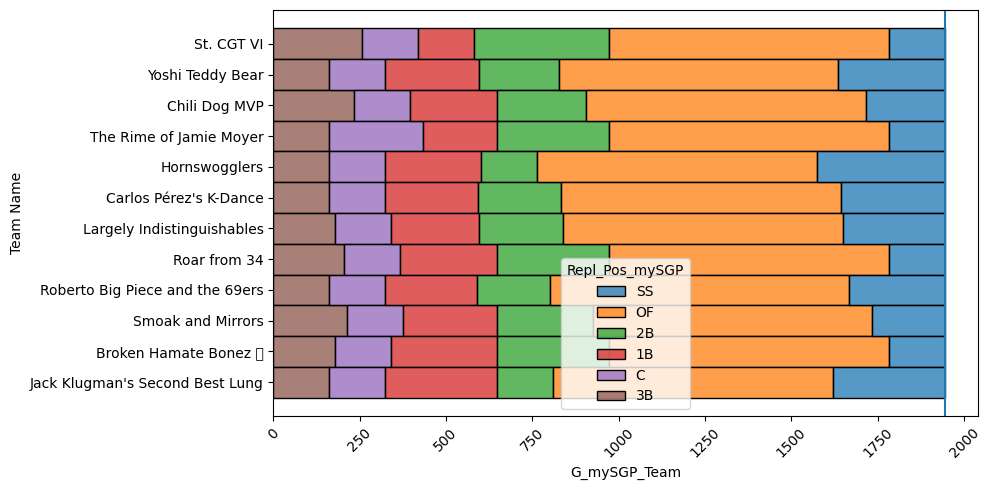

,Team Name,PA_mySGP_Team,rank
0,Chili Dog MVP,8152.99,12.0
1,Yoshi Teddy Bear,8160.40,11.0
2,Largely Indistinguishables,8163.34,10.0
3,St. CGT VI,8176.30,9.0
4,Carlos Pérez's K-Dance,8183.30,8.0
5,Jack Klugman's Second Best Lung,8187.40,7.0
6,Broken Hamate Bonez 🦴,8195.62,6.0
7,Roar from 34,8200.26,5.0
8,Smoak and Mirrors,8203.92,4.0
9,Hornswogglers,8217.06,3.0


Index(['Target Pts', 'R_mySGP_Team', 'HR_mySGP_Team', 'OBP_Team', 'SLG_Team',
       'G_mySGP_Team', 'G_FGAV_Team', 'TOTAL_SGP_Val_mySGP',
       'R_SGP_Val_mySGP_Team', 'HR_SGP_Val_mySGP_Team',
       'OBP_SGP_Val_mySGP_Team', 'SLG_SGP_Val_mySGP_Team', 'Salary',
       'Hitter Pitcher'],
      dtype='str')


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_58647/3066415080.py:46: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


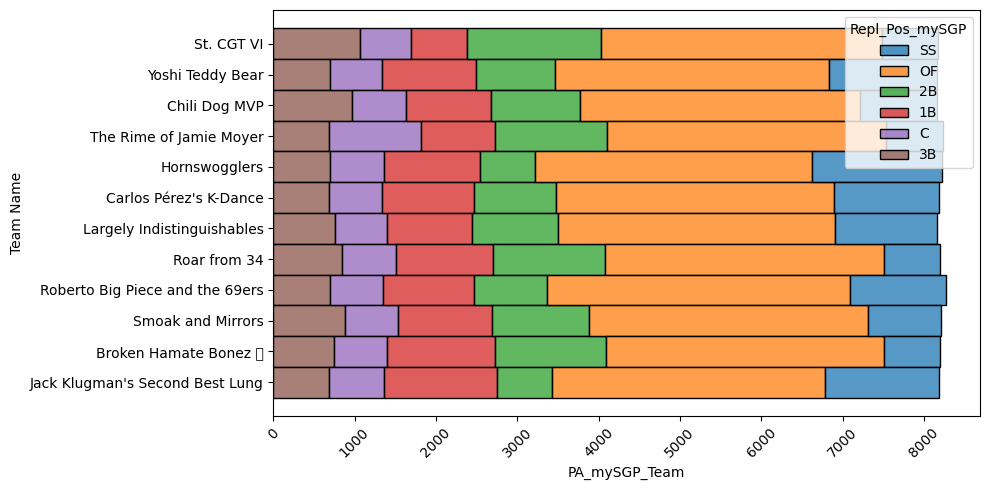

,Team Name,PA_FGAV_Team,rank
0,Chili Dog MVP,8266.19,12.0
1,Yoshi Teddy Bear,8268.59,11.0
2,St. CGT VI,8275.90,10.0
3,Jack Klugman's Second Best Lung,8280.71,9.0
4,Roar from 34,8281.45,8.0
5,Largely Indistinguishables,8315.07,7.0
6,Smoak and Mirrors,8322.01,6.0
7,Broken Hamate Bonez 🦴,8346.35,5.0
8,Carlos Pérez's K-Dance,8384.61,4.0
9,Hornswogglers,8412.61,3.0


Index(['Target Pts', 'R_mySGP_Team', 'HR_mySGP_Team', 'OBP_Team', 'SLG_Team',
       'G_mySGP_Team', 'G_FGAV_Team', 'TOTAL_SGP_Val_mySGP',
       'R_SGP_Val_mySGP_Team', 'HR_SGP_Val_mySGP_Team',
       'OBP_SGP_Val_mySGP_Team', 'SLG_SGP_Val_mySGP_Team', 'Salary',
       'Hitter Pitcher'],
      dtype='str')


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_58647/3066415080.py:46: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


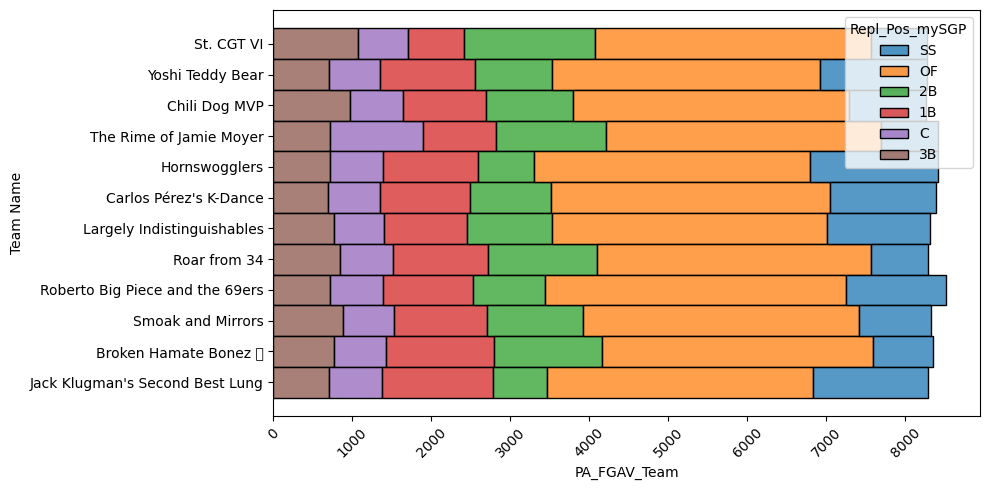

,Team Name,Salary,rank
0,Jack Klugman's Second Best Lung,229.0,12.0
1,Chili Dog MVP,255.0,11.0
2,Smoak and Mirrors,264.0,10.0
3,Largely Indistinguishables,282.0,9.0
4,The Rime of Jamie Moyer,294.0,8.0
5,Carlos Pérez's K-Dance,326.0,7.0
6,Yoshi Teddy Bear,335.0,6.0
7,Roar from 34,340.0,5.0
8,Hornswogglers,347.0,4.0
9,Roberto Big Piece and the 69ers,368.0,3.0


Target Salary: 380.0
Largely Indistinguishables with Replacement Players: 282.0
Delta: -98.0


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_58647/3066415080.py:46: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


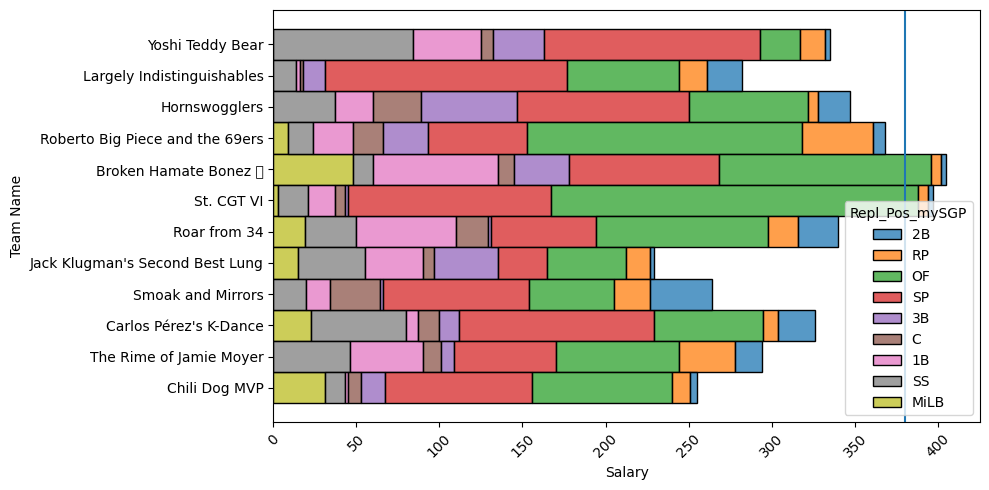

,Team Name,R_mySGP_Team,rank
0,Chili Dog MVP,984.07,12.0
1,Jack Klugman's Second Best Lung,1000.73,11.0
2,Carlos Pérez's K-Dance,1006.62,10.0
3,Broken Hamate Bonez 🦴,1007.12,9.0
4,Smoak and Mirrors,1012.23,8.0
5,Yoshi Teddy Bear,1014.03,7.0
6,Largely Indistinguishables,1021.20,6.0
7,The Rime of Jamie Moyer,1039.46,5.0
8,St. CGT VI,1042.39,4.0
9,Roar from 34,1047.92,3.0


Target R_mySGP_Team: 1073.3416660079588
Largely Indistinguishables with Replacement Players: 1021.1990895898199
Delta: -52.1425764181389


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_58647/3066415080.py:46: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


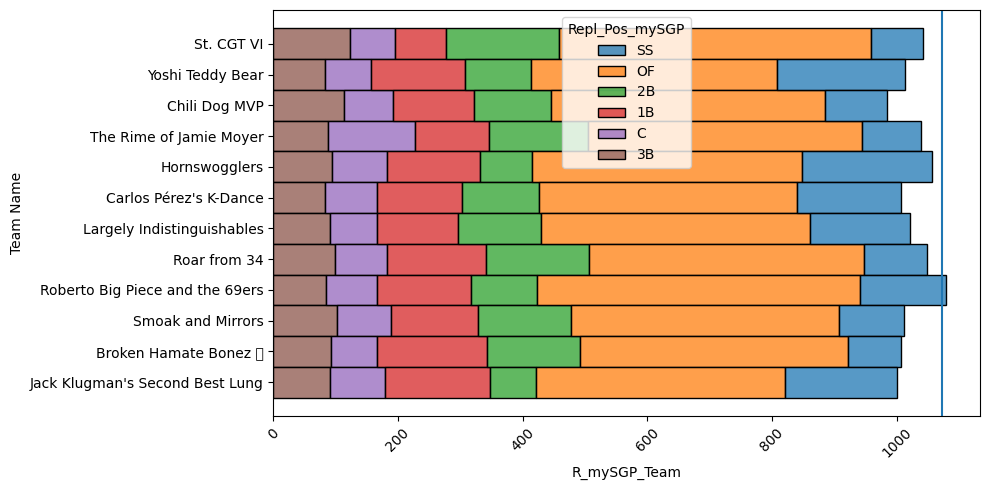

,Team Name,R_SGP_Val_mySGP_Team,rank
0,Broken Hamate Bonez 🦴,111.52,12.0
1,Chili Dog MVP,113.86,11.0
2,Jack Klugman's Second Best Lung,135.36,10.0
3,Largely Indistinguishables,136.52,9.0
4,Smoak and Mirrors,152.96,8.0
5,Carlos Pérez's K-Dance,153.71,7.0
6,Yoshi Teddy Bear,158.95,6.0
7,The Rime of Jamie Moyer,186.77,5.0
8,St. CGT VI,192.27,4.0
9,Roar from 34,194.57,3.0


Target R_SGP_Val_mySGP_Team: 200.0
Largely Indistinguishables with Replacement Players: 136.51598981631088
Delta: -63.48401018368912


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_58647/3066415080.py:46: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


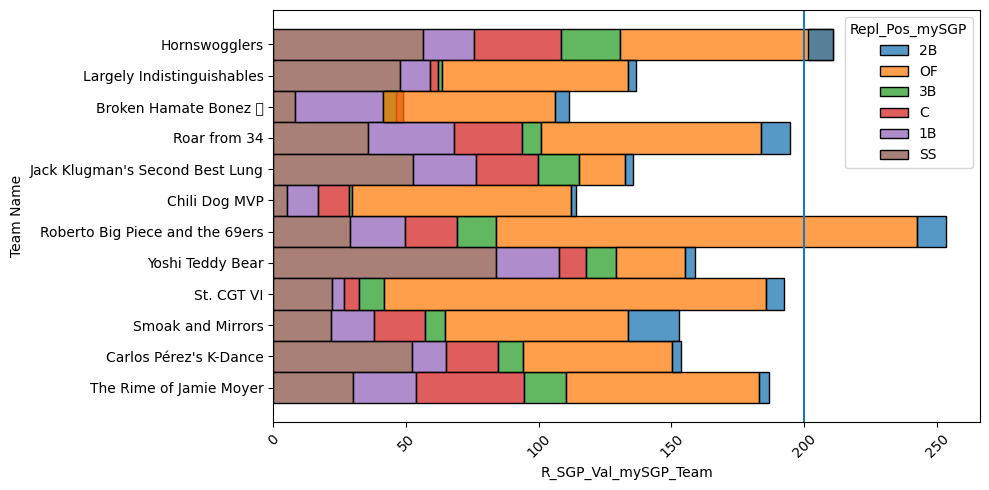

,Team Name,HR_mySGP_Team,rank
0,Largely Indistinguishables,263.06,12.0
1,Chili Dog MVP,265.12,11.0
2,Yoshi Teddy Bear,269.94,10.0
3,Smoak and Mirrors,275.52,9.0
4,Jack Klugman's Second Best Lung,287.99,8.0
5,Carlos Pérez's K-Dance,289.31,7.0
6,Broken Hamate Bonez 🦴,293.46,6.0
7,Hornswogglers,294.89,5.0
8,Roar from 34,300.40,4.0
9,The Rime of Jamie Moyer,301.94,3.0


Target HR_mySGP_Team: 323.0227703382613
Largely Indistinguishables with Replacement Players: 263.05901464534594
Delta: -59.963755692915356


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_58647/3066415080.py:46: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


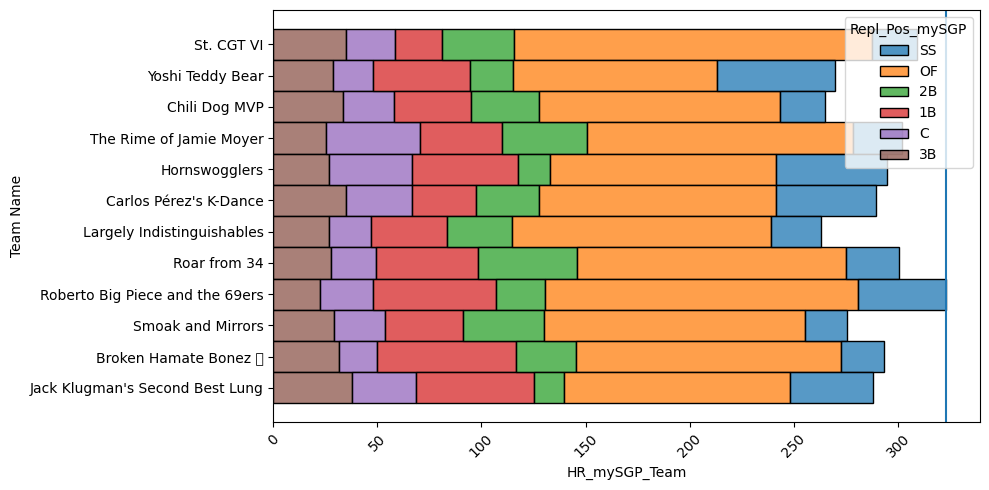

,Team Name,HR_SGP_Val_mySGP_Team,rank
0,Largely Indistinguishables,107.05,12.0
1,Chili Dog MVP,114.33,11.0
2,Yoshi Teddy Bear,135.33,10.0
3,Smoak and Mirrors,140.50,9.0
4,Broken Hamate Bonez 🦴,152.48,8.0
5,Jack Klugman's Second Best Lung,155.45,7.0
6,Carlos Pérez's K-Dance,165.84,6.0
7,Hornswogglers,180.33,5.0
8,Roar from 34,188.79,4.0
9,The Rime of Jamie Moyer,193.66,3.0


Target HR_SGP_Val_mySGP_Team: 200.0
Largely Indistinguishables with Replacement Players: 107.05104129684216
Delta: -92.94895870315784


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_58647/3066415080.py:46: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


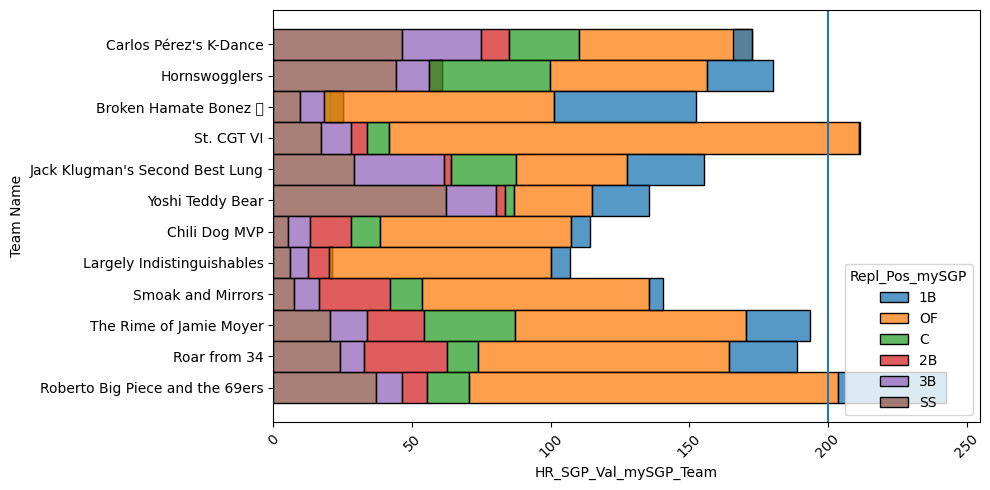

,Team Name,OBP_Team,rank
0,Chili Dog MVP,0.32,12.0
1,Jack Klugman's Second Best Lung,0.32,11.0
2,Carlos Pérez's K-Dance,0.32,10.0
3,Yoshi Teddy Bear,0.33,9.0
4,Broken Hamate Bonez 🦴,0.33,8.0
5,The Rime of Jamie Moyer,0.33,7.0
6,Roar from 34,0.33,6.0
7,Hornswogglers,0.33,5.0
8,Smoak and Mirrors,0.33,4.0
9,Largely Indistinguishables,0.33,3.0


Target OBP_Team: 0.3397449152807073
Largely Indistinguishables with Replacement Players: 0.3299590698908803
Delta: -0.00978584538982702


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_58647/3066415080.py:46: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


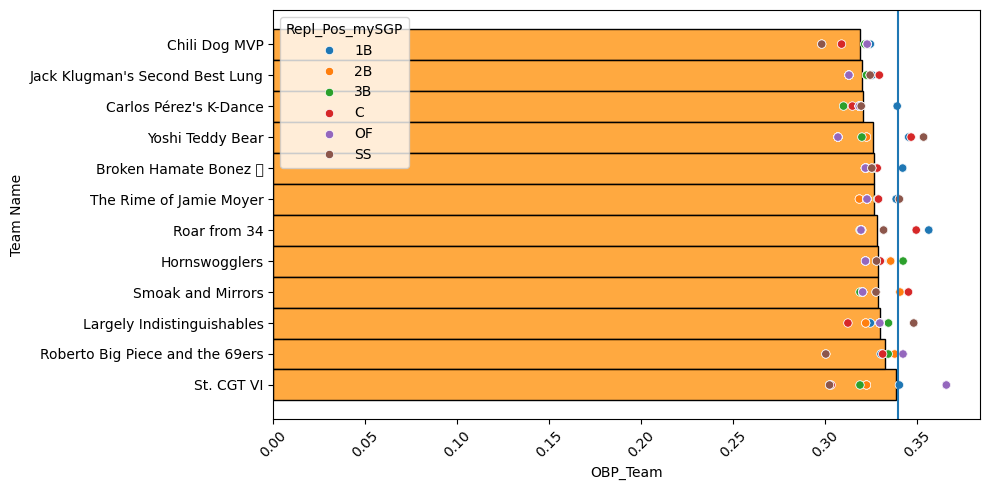

,Team Name,OBP_SGP_Val_mySGP_Team,rank
0,Carlos Pérez's K-Dance,105.10,12.0
1,Jack Klugman's Second Best Lung,122.54,11.0
2,Chili Dog MVP,123.77,10.0
3,Hornswogglers,176.57,9.0
4,Broken Hamate Bonez 🦴,185.77,8.0
5,The Rime of Jamie Moyer,189.67,7.0
6,Roar from 34,209.07,6.0
7,Yoshi Teddy Bear,211.21,5.0
8,Roberto Big Piece and the 69ers,213.67,4.0
9,Smoak and Mirrors,221.33,3.0


Target OBP_SGP_Val_mySGP_Team: 200.0
Largely Indistinguishables with Replacement Players: 234.52215008236402
Delta: 34.52215008236402


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_58647/3066415080.py:46: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


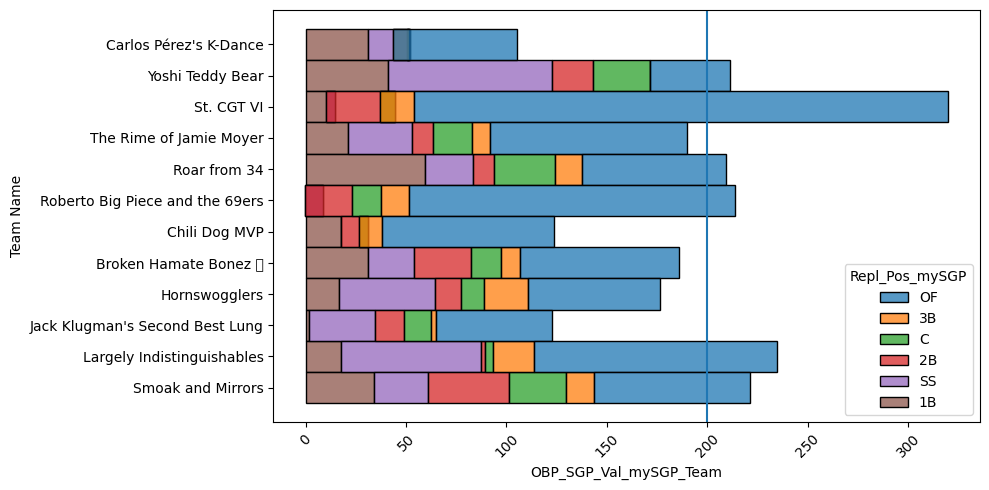

,Team Name,SLG_Team,rank
0,Chili Dog MVP,0.41,12.0
1,Largely Indistinguishables,0.42,11.0
2,Carlos Pérez's K-Dance,0.42,10.0
3,Smoak and Mirrors,0.42,9.0
4,Jack Klugman's Second Best Lung,0.43,8.0
5,Broken Hamate Bonez 🦴,0.43,7.0
6,Yoshi Teddy Bear,0.43,6.0
7,The Rime of Jamie Moyer,0.43,5.0
8,Roar from 34,0.44,4.0
9,Hornswogglers,0.44,3.0


Target SLG_Team: 0.45854447277673094
Largely Indistinguishables with Replacement Players: 0.4163746847262746
Delta: -0.04216978805045635


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_58647/3066415080.py:46: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


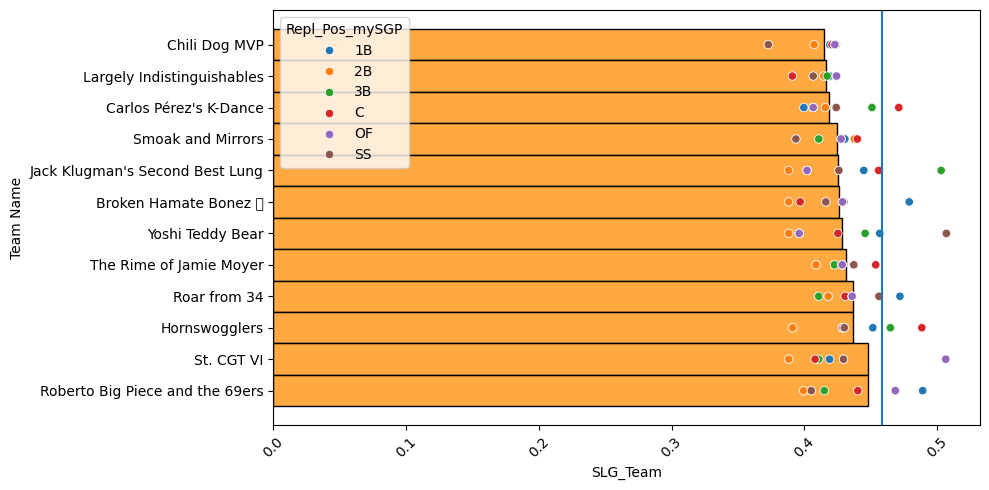

,Team Name,SLG_SGP_Val_mySGP_Team,rank
0,Carlos Pérez's K-Dance,130.68,12.0
1,Chili Dog MVP,147.19,11.0
2,Largely Indistinguishables,149.06,10.0
3,Jack Klugman's Second Best Lung,179.30,9.0
4,Broken Hamate Bonez 🦴,180.72,8.0
5,Smoak and Mirrors,181.47,7.0
6,Hornswogglers,190.99,6.0
7,The Rime of Jamie Moyer,209.69,5.0
8,Yoshi Teddy Bear,214.81,4.0
9,Roar from 34,226.57,3.0


Target SLG_SGP_Val_mySGP_Team: 200.0
Largely Indistinguishables with Replacement Players: 149.06096277239487
Delta: -50.93903722760513


/var/folders/ff/x5xtp77s2550mw4sdzk1t84m0000gn/T/ipykernel_58647/3066415080.py:46: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/cmartin/Fantasy_Baseball/Ottoneu_Baseball_Projects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


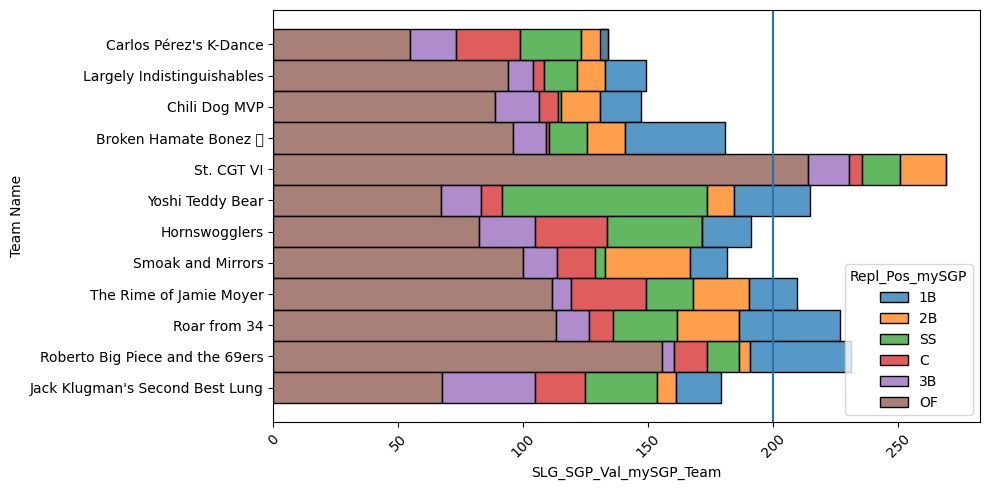

In [27]:
for pos in ['SP','Util']:
    This_Pos_Stat_Cats = Pitching_value_columns if pos in Pitching_Pos else Batting_value_columns
    for stat_cat, stat_cols in This_Pos_Stat_Cats.items():
        # if Stat in bugged_cols:
        #     continue
        # print(pos)
        # print(stat_cat)
        # print(All_teams_replacement_level[stat_cat])
        # fig1 = plt.figure(figsize=(10,5))
        # ax1 = fig1.add_subplot(111)
        # sns.histplot(All_teams_replacement_level,x='Team Name',weights=stat_cat,hue='Ottoneu Positions', multiple='stack',ax=ax1)
        # ax1.axhline(y=Target_Stats_df[stat_cat])
        # plt.tight_layout()
        # plt.show()
        
        

        for stat in stat_cols:
            # print(stat)
            fig2 = plt.figure(figsize=(10,5))
            ax2 = fig2.add_subplot(111)
            my_team_currently = 0.
            if stat in Team_Rate_Cols:
                sns.histplot(All_Teams_df[All_Teams_df['Repl_Pos_mySGP'].isin(Pitching_Pos if pos in Pitching_Pos else Hitting_Pos) if stat not in ['TOTAL_SGP_Val_mySGP','Salary'] else [True]*len(All_Teams_df)].dropna(subset=stat).groupby('Team Name')[stat].mean().sort_values().reset_index(),y='Team Name',weights=stat,color='darkorange',ax=ax2)
                sns.scatterplot(All_Teams_df[All_Teams_df['Repl_Pos_mySGP'].isin(Pitching_Pos if pos in Pitching_Pos else Hitting_Pos) if stat not in ['TOTAL_SGP_Val_mySGP','Salary'] else [True]*len(All_Teams_df)].dropna(subset=stat.replace('_','_pos_')),y='Team Name',x=stat.replace('_','_pos_'),hue='Repl_Pos_mySGP',ax=ax2)
                team_mean_df = All_Teams_df[All_Teams_df['Repl_Pos_mySGP'].isin(Pitching_Pos if pos in Pitching_Pos else Hitting_Pos) if stat not in ['TOTAL_SGP_Val_mySGP','Salary'] else [True]*len(All_Teams_df)].dropna(subset=stat).groupby('Team Name')[stat].mean().sort_values().reset_index()
                team_mean_df['rank'] = team_mean_df[stat].rank(ascending=False)
                display(team_mean_df)
                my_team_currently = team_mean_df[team_mean_df['Team Name'] == 'Largely Indistinguishables'][stat].unique()[0]
            else:
                sns.histplot(All_Teams_df[All_Teams_df['Repl_Pos_mySGP'].isin(Pitching_Pos if pos in Pitching_Pos else Hitting_Pos) if stat not in ['TOTAL_SGP_Val_mySGP','Salary'] else [True]*len(All_Teams_df)].dropna(subset=stat).sort_values(stat),y='Team Name',weights=stat,hue='Repl_Pos_mySGP', multiple='stack',ax=ax2)
                team_sum_df = All_Teams_df[All_Teams_df['Repl_Pos_mySGP'].isin(Pitching_Pos if pos in Pitching_Pos else Hitting_Pos) if stat not in ['TOTAL_SGP_Val_mySGP','Salary'] else [True]*len(All_Teams_df)].dropna(subset=stat).groupby('Team Name')[stat].sum().sort_values().reset_index()
                team_sum_df['rank'] = team_sum_df[stat].rank(ascending=False)
                display(team_sum_df)
                my_team_currently = team_sum_df[team_sum_df['Team Name'] == 'Largely Indistinguishables'][stat].unique()[0]
            ax2.tick_params(axis='x', labelrotation=45)
            ax2.set_xlabel(stat)
            ax2.set_ylabel('Team Name')
            if (stat in Target_Stats_df[Target_Stats_df['Hitter Pitcher'] == ('Pitcher' if pos in Pitching_Pos else 'Hitter')].dropna(axis=1).columns):
                ax2.axvline(x=Target_Stats_df[Target_Stats_df['Hitter Pitcher'] == ('Pitcher' if pos in Pitching_Pos else 'Hitter')][stat].unique()[0],label='Target')
                print(f'Target {stat}:', Target_Stats_df[Target_Stats_df['Hitter Pitcher'] == ('Pitcher' if pos in Pitching_Pos else 'Hitter')][stat].unique()[0])
                print('Largely Indistinguishables with Replacement Players:',my_team_currently)
                print(f'Delta:', my_team_currently - Target_Stats_df[Target_Stats_df['Hitter Pitcher'] == ('Pitcher' if pos in Pitching_Pos else 'Hitter')][stat].unique()[0])
            else:
                print(Target_Stats_df[Target_Stats_df['Hitter Pitcher'] == ('Pitcher' if pos in Pitching_Pos else 'Hitter')].dropna(axis=1).columns)
            plt.tight_layout()
            plt.show()
            #sns.histplot(All_teams_replacement_level.dropna(subset=stat),y=stat,hue=)